# CH3CN T3NS 12dim 125N CBC mu0

This notebook uses `SVD_MAX_BOND_DIM = 12` and `CHEB_TTNS_BASIS_SIZE = 125`, with only the CBC contraction method enabled. The rescaling window and ground state `psi_min` are estimated by DMRG.


In [631]:
import importlib
import copy
import time
import traceback
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from Experiment.potentials import get_potential_energy_CH3CN, get_potential_energy_CH3CN_harmonic
from Experiment.utils import get_orbitals_indices_first, get_energy_clusters, get_ttno
from Experiment.utils_ch3cn import random_mps_harmonic_oscillator_0, random_threetree_harmonic_oscillator_0, random_leafonly_harmonic_oscillator_0
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.ttns.ttns_ttno.application import ApplicationMethod
from pytreenet.operators.models.two_site_model import XYModel
from pytreenet.operators.common_operators import *
from pytreenet.util import SVDParameters
from Dipole_moment import get_mu_ttno_linear
import utils_CH3CN as ch3cn_utils
from CheTTNS import *
ch3cn_utils = importlib.reload(ch3cn_utils)
CH3CN_IR_FREQ_CM_12 = ch3cn_utils.CH3CN_IR_FREQ_CM_12
CH3CN_IR_TRANSITION_DIPOLE_12 = ch3cn_utils.CH3CN_IR_TRANSITION_DIPOLE_12
CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12 = ch3cn_utils.CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12
get_ch3cn_ir_dipole_derivative = ch3cn_utils.get_ch3cn_ir_dipole_derivative
get_ch3cn_orca_permanent_dipole = ch3cn_utils.get_ch3cn_orca_permanent_dipole
get_ch3cn_orca_potential_energy = ch3cn_utils.get_ch3cn_orca_potential_energy


### CH3CN Hamiltonian


In [632]:
N = [9,7,9,9,9,9,7,7,9,9,27,27]
node_order = [0,1,2,3,4,5,6,7,8,9,10,11]

# Keep the ORCA TTNO manageable. Set this to 0.0 for the full ORCA VPT2
# force field; increase to 5.0 if TTNO construction becomes too heavy.
ORCA_FORCE_CONSTANT_CUTOFF_CM = 1.0

omega_experiment, _, _ = get_potential_energy_CH3CN_harmonic()
omega, k3_orca, k4_orca = get_ch3cn_orca_potential_energy(
    force_constant_cutoff_cm=ORCA_FORCE_CONSTANT_CUTOFF_CM,
)


def get_potential_energy_CH3CN_orca(alpha=1000):
    return get_ch3cn_orca_potential_energy(
        alpha=alpha,
        force_constant_cutoff_cm=ORCA_FORCE_CONSTANT_CUTOFF_CM,
    )


TTNS_NUM_ORB = 2
_, orb_state, orb_Es = get_orbitals_indices_first(omega_experiment, num_orb=TTNS_NUM_ORB)

state0 = random_threetree_harmonic_oscillator_0(N, omega_experiment, orb_state[:TTNS_NUM_ORB], node_order)

state0.canonical_form(state0.root_id)

ttno, _ = get_ttno(N, state0, get_potential_energy_CH3CN, True)

site_ids = list(state0.nodes.keys())
print("Number of sites:", len(site_ids))
print("Site ids:", site_ids)
print("Experiment harmonic omega cm^-1:", np.asarray(omega_experiment) * 1000.0)
print("ORCA harmonic omega cm^-1:", omega * 1000.0)
print("ORCA VPT2 fundamental cm^-1:", CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12)
print("ORCA - Experiment harmonic cm^-1:", omega * 1000.0 - np.asarray(omega_experiment) * 1000.0)
print("ORCA k3 nonzero:", int(np.count_nonzero(k3_orca)))
print("ORCA k4 nonzero:", int(np.count_nonzero(k4_orca)))
print("TTNS num_orb:", TTNS_NUM_ORB)
print("orb_Es:", orb_Es[:TTNS_NUM_ORB])
print("TTNO bond dims:", ttno.bond_dims())


/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/pytreenet/random/random_node.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  rand_tensor = crandn(shape, seed=seed).astype(dtype)


Number of sites: 13
Site ids: ['site12', 'site3', 'site2', 'site1', 'site0', 'site4', 'site5', 'site6', 'site7', 'site8', 'site9', 'site10', 'site11']
Experiment harmonic omega cm^-1: [3065. 2297. 1413.  920. 3149. 3149. 1487. 1487. 1061. 1061.  361.  361.]
ORCA harmonic omega cm^-1: [3048.42 2364.22 1413.32  929.02 3116.15 3116.39 1473.16 1473.19 1062.64
 1062.8   381.75  381.8 ]
ORCA VPT2 fundamental cm^-1: [2938.213 2338.018 1378.792  922.32  2972.062 2971.824 1444.841 1444.94
 1041.41  1041.275  383.882  383.631]
ORCA - Experiment harmonic cm^-1: [-16.58  67.22   0.32   9.02 -32.85 -32.61 -13.84 -13.81   1.64   1.8
  20.75  20.8 ]
ORCA k3 nonzero: 215
ORCA k4 nonzero: 338
TTNS num_orb: 2
orb_Es: [ 9.9055 10.2665]
TTNO bond dims: {('site12', 'site3'): 14, ('site3', 'site2'): 11, ('site2', 'site1'): 9, ('site1', 'site0'): 5, ('site12', 'site4'): 18, ('site4', 'site5'): 16, ('site5', 'site6'): 10, ('site6', 'site7'): 5, ('site12', 'site8'): 18, ('site8', 'site9'): 13, ('site9', 'site1

### Construct dipole moment


In [633]:
# ORCA harmonic transition dipoles in site order:
# [nu1, nu2, nu3, nu4, nu5a, nu5b, nu6a, nu6b, nu7a, nu7b, nu8a, nu8b]
# Use Tx/Ty/Tz separately. The total IR response is the sum of the three
# component spectra.
DIPOLE_COMPONENTS = ("x", "y", "z")
DIPOLE_INCLUDE_MU0 = False
CENTER_DIPOLE_WITH_PSI_MIN = True
dipole_mu0_by_component = dict(
    zip(DIPOLE_COMPONENTS, get_ch3cn_orca_permanent_dipole())
)
dipole_base_mu0_by_component = {
    component: dipole_mu0_by_component[component] if DIPOLE_INCLUDE_MU0 else 0.0
    for component in DIPOLE_COMPONENTS
}
dipole_derivative_by_component = {
    component: get_ch3cn_ir_dipole_derivative(normalize=False, component=component)
    for component in DIPOLE_COMPONENTS
}
transition_dipole_12 = np.column_stack(
    [dipole_derivative_by_component[component] for component in DIPOLE_COMPONENTS]
)

print("ORCA transition dipole components [Tx, Ty, Tz]:")
print(transition_dipole_12)
print("ORCA permanent dipole mu0 [x, y, z]:")
print([dipole_mu0_by_component[component] for component in DIPOLE_COMPONENTS])
print("DIPOLE_INCLUDE_MU0:", DIPOLE_INCLUDE_MU0)
print("CENTER_DIPOLE_WITH_PSI_MIN:", CENTER_DIPOLE_WITH_PSI_MIN)

mu_ttno_with_mu0_by_component = {
    component: get_mu_ttno_linear(
        N,
        state0,
        dipole_derivative_by_component[component],
        mu0=dipole_mu0_by_component[component],
    )
    for component in DIPOLE_COMPONENTS
}
mu_ttno_raw_by_component = {
    component: get_mu_ttno_linear(
        N,
        state0,
        dipole_derivative_by_component[component],
        mu0=0.0,
    )
    for component in DIPOLE_COMPONENTS
}

mu_ttno_by_component = (
    mu_ttno_with_mu0_by_component
    if DIPOLE_INCLUDE_MU0
    else mu_ttno_raw_by_component
)
mu_x_ttno = mu_ttno_by_component["x"]
mu_y_ttno = mu_ttno_by_component["y"]
mu_z_ttno = mu_ttno_by_component["z"]

for component in DIPOLE_COMPONENTS:
    print(f"mu_{component} with mu0 TTNO bond dims:", mu_ttno_with_mu0_by_component[component].bond_dims())
    print(f"mu_{component} no mu0 TTNO bond dims:", mu_ttno_raw_by_component[component].bond_dims())


ORCA transition dipole components [Tx, Ty, Tz]:
[[-7.8150e-03 -3.2000e-05 -1.0000e-06]
 [-1.6558e-02  2.0000e-06 -1.0000e-06]
 [-8.6240e-03 -3.2000e-05 -1.0000e-06]
 [-9.1340e-03  0.0000e+00  0.0000e+00]
 [ 2.5000e-05 -4.1430e-03 -3.2300e-04]
 [-1.0000e-06 -3.2000e-04  4.1780e-03]
 [ 2.0000e-06  1.3390e-03 -2.0902e-02]
 [ 9.0000e-06  2.0896e-02  1.3390e-03]
 [-2.0000e-06 -1.7300e-04 -1.0266e-02]
 [ 4.4000e-05 -1.0321e-02  1.7000e-04]
 [ 0.0000e+00 -3.1300e-04  1.0057e-02]
 [ 5.5000e-05  1.0026e-02  3.1400e-04]]
ORCA permanent dipole mu0 [x, y, z]:
[np.float64(0.161359895), np.float64(-0.092676601), np.float64(-1.574578465)]
DIPOLE_INCLUDE_MU0: False
CENTER_DIPOLE_WITH_PSI_MIN: True
mu_x with mu0 TTNO bond dims: {('site12', 'site3'): 2, ('site3', 'site2'): 2, ('site2', 'site1'): 2, ('site1', 'site0'): 2, ('site12', 'site4'): 2, ('site4', 'site5'): 2, ('site5', 'site6'): 2, ('site6', 'site7'): 2, ('site12', 'site8'): 2, ('site8', 'site9'): 2, ('site9', 'site10'): 2, ('site10', 'site11'):

### Rescale Hamiltonian


In [ ]:
from pathlib import Path

RESCALE_MAX_BOND_DIM = 12
RESCALE_NUM_SWEEPS = 1
RESCALE_MAX_ITER = 40
RESCALE_DMRG_SITE = "two-site"
RESCALE_W_PRIME = 0.9875
RESCALE_SAFETY_FACTOR = 1.10
RESCALE_CHECK_LIMIT = 0.999
RESCALE_ADAPTIVE_CHECK = False
RUN_RESCALE_CHECK = False

THREETREE_GROUND_RESULTS_DIR = Path(
    "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/Results_final/ch3cn/threetree/max_bond_dim_12"
)
THREETREE_E_MIN_ENERGY_FILE = "inverse_iteration_energies_20.csv"
THREETREE_PSI_MIN_STATE_INDEX = 0
THREETREE_PSI_MIN_STATE_TEMPLATE = "lobpcg_state_{state_index}"


def read_ground_energy(results_dir, energy_file_name=THREETREE_E_MIN_ENERGY_FILE):
    results_dir = Path(results_dir)
    energy_path = results_dir / energy_file_name
    if not energy_path.is_file():
        raise FileNotFoundError(energy_path)

    energy_history = np.loadtxt(energy_path, delimiter=",", dtype=np.complex128)
    energy_history = np.atleast_2d(energy_history)
    final_energies = energy_history[:, -1].real.astype(np.float64)
    ground_state_index = int(np.argmin(final_energies))
    ground_energy = float(final_energies[ground_state_index])
    return ground_energy, ground_state_index, energy_path


def load_threetree_psi_min(
    results_dir,
    state_index=THREETREE_PSI_MIN_STATE_INDEX,
    state_template=THREETREE_PSI_MIN_STATE_TEMPLATE,
):
    results_dir = Path(results_dir)
    state_base = results_dir / "states" / state_template.format(state_index=state_index)
    if not state_base.with_suffix(".json").is_file() or not state_base.with_suffix(".npz").is_file():
        raise FileNotFoundError(str(state_base) + ".{json,npz}")

    state = TreeTensorNetworkState.load(str(state_base))
    state.normalise()
    return state, state_index, state_base


(
    threetree_ground_energy,
    threetree_ground_energy_index,
    threetree_ground_energy_path,
) = read_ground_energy(THREETREE_GROUND_RESULTS_DIR)

(
    threetree_ground_ttns,
    threetree_psi_min_state_index,
    threetree_ground_state_base,
) = load_threetree_psi_min(THREETREE_GROUND_RESULTS_DIR)

E_min = threetree_ground_energy
E_max = 298.1865028266525
H_scaled, a, shift = scale_ttno_with_energy_window(
    ttno,
    E_min=E_min,
    E_max=E_max,
    W_prime=RESCALE_W_PRIME,
    safety_factor=RESCALE_SAFETY_FACTOR,
)

psi_min = copy.deepcopy(threetree_ground_ttns)
psi_min.normalise()

print("E_min:", E_min)
print("E_max:", E_max)
print("a:", a)
print("shift:", shift)
print("W_prime:", RESCALE_W_PRIME)
print("safety_factor:", RESCALE_SAFETY_FACTOR)
print("DMRG site:", RESCALE_DMRG_SITE)
print("E_min source energy:", threetree_ground_energy)
print("E_min source index:", threetree_ground_energy_index)
print("E_min energy path:", threetree_ground_energy_path)
print("psi_min state index:", threetree_psi_min_state_index)
print("psi_min path:", threetree_ground_state_base)
print("psi_min norm:", psi_min.scalar_product())

dipole_expectation_by_component = {
    component: psi_min.operator_expectation_value(mu_ttno_by_component[component])
    for component in DIPOLE_COMPONENTS
}
dipole_expectation_by_component = {
    component: float(np.real_if_close(value, tol=1000))
    for component, value in dipole_expectation_by_component.items()
}

if CENTER_DIPOLE_WITH_PSI_MIN:
    dipole_centered_mu0_by_component = {
        component: dipole_base_mu0_by_component[component] - dipole_expectation_by_component[component]
        for component in DIPOLE_COMPONENTS
    }
    mu_ttno_centered_by_component = {
        component: get_mu_ttno_linear(
            N,
            state0,
            dipole_derivative_by_component[component],
            mu0=dipole_centered_mu0_by_component[component],
        )
        for component in DIPOLE_COMPONENTS
    }
    mu_ttno_by_component = mu_ttno_centered_by_component
    mu_x_ttno = mu_ttno_by_component["x"]
    mu_y_ttno = mu_ttno_by_component["y"]
    mu_z_ttno = mu_ttno_by_component["z"]

for component in DIPOLE_COMPONENTS:
    print(f"mu_{component} <psi_min|mu|psi_min> before centering:", dipole_expectation_by_component[component])
    if CENTER_DIPOLE_WITH_PSI_MIN:
        centered_check = psi_min.operator_expectation_value(mu_ttno_by_component[component])
        print(f"mu_{component} centered mu0 constant:", dipole_centered_mu0_by_component[component])
        print(f"mu_{component} centered TTNO bond dims:", mu_ttno_by_component[component].bond_dims())
        print(f"mu_{component} <psi_min|mu_centered|psi_min>:", centered_check)

if RUN_RESCALE_CHECK:
    E_min_scaled_check, E_max_scaled_check, _ = dmrg_min_max_limited_ch3cn(
        state0,
        H_scaled,
        max_bond_dim=RESCALE_MAX_BOND_DIM,
        num_sweeps=RESCALE_NUM_SWEEPS,
        max_iter=RESCALE_MAX_ITER,
        site=RESCALE_DMRG_SITE,
    )
    E_min_rescale = E_min_scaled_check
    E_max_rescale = E_max_scaled_check
    print("E_min_rescale:", E_min_rescale)
    print("E_max_rescale:", E_max_rescale)

    if RESCALE_ADAPTIVE_CHECK and (E_min_rescale < -RESCALE_CHECK_LIMIT or E_max_rescale > RESCALE_CHECK_LIMIT):
        checked_abs_E_min = (E_min_scaled_check + shift) * a
        checked_abs_E_max = (E_max_scaled_check + shift) * a
        E_min = min(E_min, checked_abs_E_min)
        E_max = max(E_max, checked_abs_E_max)
        print("Rescale check exceeded target; rebuilding H_scaled with checked absolute energy window.")
        print("checked_abs_E_min:", checked_abs_E_min)
        print("checked_abs_E_max:", checked_abs_E_max)
        H_scaled, a, shift = scale_ttno_with_energy_window(
            ttno,
            E_min=E_min,
            E_max=E_max,
            W_prime=RESCALE_W_PRIME,
            safety_factor=RESCALE_SAFETY_FACTOR,
        )
        print("updated E_min:", E_min)
        print("updated E_max:", E_max)
        print("updated a:", a)
        print("updated shift:", shift)

        E_min_scaled_check, E_max_scaled_check, _ = dmrg_min_max_limited_ch3cn(
            state0,
            H_scaled,
            max_bond_dim=RESCALE_MAX_BOND_DIM,
            num_sweeps=RESCALE_NUM_SWEEPS,
            max_iter=RESCALE_MAX_ITER,
            site=RESCALE_DMRG_SITE,
        )
        E_min_rescale = E_min_scaled_check
        E_max_rescale = E_max_scaled_check
        print("updated E_min_rescale:", E_min_rescale)
        print("updated E_max_rescale:", E_max_rescale)
else:
    E_min_rescale = np.nan
    E_max_rescale = np.nan
    print("Skipped extra rescale DMRG check. Set RUN_RESCALE_CHECK=True if needed.")


E_min: 9.83746358867246
E_max: 298.29175355237453
a: 160.6580855494037
shift: 1.048732296868416
W_prime: 0.9875
safety_factor: 1.1
DMRG site: two-site
psi_min norm: (1.0000000000000002+0j)
mu_x <psi_min|mu|psi_min> before centering: -0.004242136799990663
mu_x centered mu0 constant: 0.004242136799990663
mu_x centered TTNO bond dims: {('site12', 'site3'): 2, ('site3', 'site2'): 2, ('site2', 'site1'): 2, ('site1', 'site0'): 2, ('site12', 'site4'): 2, ('site4', 'site5'): 2, ('site5', 'site6'): 2, ('site6', 'site7'): 2, ('site12', 'site8'): 2, ('site8', 'site9'): 2, ('site9', 'site10'): 2, ('site10', 'site11'): 2}
mu_x <psi_min|mu_centered|psi_min>: (9.330161339093222e-15+0j)
mu_y <psi_min|mu|psi_min> before centering: -8.20424593067079e-06
mu_y centered mu0 constant: 8.20424593067079e-06
mu_y centered TTNO bond dims: {('site12', 'site3'): 2, ('site3', 'site2'): 2, ('site2', 'site1'): 2, ('site1', 'site0'): 2, ('site12', 'site4'): 2, ('site4', 'site5'): 2, ('site5', 'site6'): 2, ('site6', '

### Compute bra and ket ttns


In [635]:
from pathlib import Path

BASIS_PRESET = "balanced"  # "quick", "balanced", or "stable"

if BASIS_PRESET == "quick":
    SVD_MAX_BOND_DIM = 12
    CHEB_TTNS_BASIS_SIZE = 120
    CHEB_TTNS_NUM_SWEEPS = 2
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 6000
    N_ENERGY_GRID = 1200
elif BASIS_PRESET == "balanced":
    SVD_MAX_BOND_DIM = 12
    CHEB_TTNS_BASIS_SIZE = 125
    CHEB_TTNS_NUM_SWEEPS = 2
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 40000
    N_ENERGY_GRID = 1600
elif BASIS_PRESET == "stable":
    SVD_MAX_BOND_DIM = 20
    CHEB_TTNS_BASIS_SIZE = 140
    CHEB_TTNS_NUM_SWEEPS = 3
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 10000
    N_ENERGY_GRID = 5000
else:
    raise ValueError(f"Unknown BASIS_PRESET: {BASIS_PRESET}")

svd_params = SVDParameters(max_bond_dim=SVD_MAX_BOND_DIM, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

USE_CACHED_CBC_RESULT = False

# Run only the CBC Chebyshev-vector builder.
CONTRACTION_METHODS = [
    ("cbc", "cheb_ttns_CBC", ApplicationMethod.HALF_DENSITY_MATRIX, cheb_ttns_CBC),
]

CHEB_TIMING_TTNS_START = 1
CHEB_TIMING_TTNS_STOP = CHEB_TTNS_BASIS_SIZE
CHEB_TIMING_SCOPE_LABEL = f"full {CHEB_TTNS_BASIS_SIZE} Chebyshev TTNS"
REFERENCE_METHOD = "cbc"
CONTRACTION_SEED = 20260613
STOP_ON_METHOD_ERROR = False

print("BASIS_PRESET:", BASIS_PRESET)
print("SVD_MAX_BOND_DIM:", SVD_MAX_BOND_DIM)
print("CHEB_TTNS_BASIS_SIZE:", CHEB_TTNS_BASIS_SIZE)
print("CHEB_TTNS_NUM_SWEEPS:", CHEB_TTNS_NUM_SWEEPS)
print("ORTH_ABS_CUT:", ORTH_ABS_CUT)
print("ORTH_REL_CUT:", ORTH_REL_CUT)
print("EFFECTIVE_CHEB_MOMENTS:", EFFECTIVE_CHEB_MOMENTS)
print("N_ENERGY_GRID:", N_ENERGY_GRID)
print("CHEB_TIMING_SCOPE:", CHEB_TIMING_SCOPE_LABEL)
print("CONTRACTION_METHODS:", [label for _, label, _, _ in CONTRACTION_METHODS])
print("REFERENCE_METHOD:", REFERENCE_METHOD)
print("USE_CACHED_CBC_RESULT:", USE_CACHED_CBC_RESULT)


BASIS_PRESET: balanced
SVD_MAX_BOND_DIM: 12
CHEB_TTNS_BASIS_SIZE: 125
CHEB_TTNS_NUM_SWEEPS: 2
ORTH_ABS_CUT: 1e-14
ORTH_REL_CUT: 1e-12
EFFECTIVE_CHEB_MOMENTS: 40000
N_ENERGY_GRID: 1600
CHEB_TIMING_SCOPE: full 125 Chebyshev TTNS
CONTRACTION_METHODS: ['cheb_ttns_CBC']
REFERENCE_METHOD: cbc
USE_CACHED_CBC_RESULT: False


In [636]:
contraction_data = {}
for method_key, method_label, method_enum, cheb_builder in CONTRACTION_METHODS:
    contraction_data[method_key] = {
        "method_key": method_key,
        "label": method_label,
        "method_enum": method_enum,
        "cheb_builder": cheb_builder,
        "status": "ok",
        "timings": {},
        "apply_calls": {},
    }

bra_ket_rows = []
for method_index, (method_key, data) in enumerate(active_method_items(contraction_data)):
    phase = "dipole apply"
    tic = time.perf_counter()
    try:
        dipole_applier = TTNOApplier(
            data["method_enum"],
            svd_params,
            seed=CONTRACTION_SEED + 10000 * method_index,
        )
        psi_ket_by_component = {}
        psi_bra_by_component = {}
        elastic_overlap_by_component = {}
        for component_index, component in enumerate(DIPOLE_COMPONENTS):
            psi_ket_c = dipole_applier.apply(
                copy.deepcopy(psi_min),
                mu_ttno_by_component[component],
            )
            elastic_overlap_c = psi_min.scalar_product(psi_ket_c)
            elastic_overlap_by_component[component] = elastic_overlap_c
            psi_ket_by_component[component] = psi_ket_c
            psi_bra_by_component[component] = copy.deepcopy(psi_ket_c)
            print(
                f"{data['label']} / {component}: psi_ket norm:", psi_ket_c.scalar_product(),
                "elastic overlap <psi_min|psi_ket>:", elastic_overlap_c,
            )

        data["psi_ket_by_component"] = psi_ket_by_component
        data["psi_bra_by_component"] = psi_bra_by_component
        data["elastic_overlap_by_component"] = elastic_overlap_by_component
        data["timings"]["dipole_phase_s"] = time.perf_counter() - tic
        data["timings"]["dipole_apply_s"] = dipole_applier.time_s
        data["apply_calls"]["dipole"] = dipole_applier.calls
        bra_ket_rows.append({
            "method": data["label"],
            "status": data["status"],
            "dipole_calls": dipole_applier.calls,
            "dipole_apply_s": dipole_applier.time_s,
            "dipole_phase_s": data["timings"]["dipole_phase_s"],
            "max_elastic_overlap": max(abs(v) for v in elastic_overlap_by_component.values()),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        bra_ket_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    bra_ket_rows,
    ["method", "status", "dipole_calls", "dipole_apply_s", "dipole_phase_s", "max_elastic_overlap"],
    title="Dipole TTNO application summary",
)


cheb_ttns_CBC / x: psi_ket norm: (0.0002491568198748494+0j) elastic overlap <psi_min|psi_ket>: (1.3446095624905614e-07+0j)
cheb_ttns_CBC / y: psi_ket norm: (0.00033376480963113753+0j) elastic overlap <psi_min|psi_ket>: (9.427756149113505e-09+0j)
cheb_ttns_CBC / z: psi_ket norm: (0.00033250789282503255+0j) elastic overlap <psi_min|psi_ket>: (1.124833754394603e-08+0j)

Dipole TTNO application summary
method         status  dipole_calls  dipole_apply_s  dipole_phase_s  max_elastic_overlap
-------------  ------  ------------  --------------  --------------  -------------------
cheb_ttns_CBC  ok      3             0.0336356       0.0480705       1.34461e-07        


### Computing Chebyshev TTNS


In [637]:
ttns_summary_rows = []

for method_index, (method_key, data) in enumerate(active_method_items(contraction_data)):
    phase = "Chebyshev TTNS build"
    try:
        ttns_list_by_component = {}
        mu_by_component = {}
        component_build_times = {}
        component_step_times = {}
        total_build_s = 0.0
        total_vectors = 0

        for component_index, component in enumerate(DIPOLE_COMPONENTS):
            print(f"\n{data['label']} / component {component}")
            tic_vectors = time.perf_counter()
            ttns_list_c, profile_c = data["cheb_builder"](
                data["psi_ket_by_component"][component],
                H_scaled,
                N=CHEB_TTNS_BASIS_SIZE,
                svd_params=svd_params,
                num_sweeps=CHEB_TTNS_NUM_SWEEPS,
                dtype=np.float64,
                profile_start_ttns=CHEB_TIMING_TTNS_START,
                profile_stop_ttns=CHEB_TIMING_TTNS_STOP,
            )
            component_build_s = time.perf_counter() - tic_vectors

            ttns_list_by_component[component] = ttns_list_c
            component_build_times[component] = component_build_s
            component_step_times[component] = profile_c
            total_build_s += component_build_s
            total_vectors += len(ttns_list_c)

            mu_by_component[component] = chebyshev_moments_ttns(
                data["psi_bra_by_component"][component],
                ttns_list_c,
            )
            print(f"{data['label']} / {component}: Chebyshev TTNS basis size:", len(ttns_list_c))
            print(f"{data['label']} / {component}: vector build time [s]:", component_build_s)
            print(
                f"{data['label']} / {component}: Hpsin/postprocess/psi_np1 time [s]:",
                profile_c["Hpsin_s"],
                profile_c["postprocess_s"],
                profile_c["psi_np1_s"],
            )
            print(f"{data['label']} / {component}: direct TTNS moments:", len(mu_by_component[component]))

        profile_total = merge_cheb_step_timings(
            component_step_times.values(),
            CHEB_TIMING_TTNS_START,
            CHEB_TIMING_TTNS_STOP,
        )
        data["ttns_list_by_component"] = ttns_list_by_component
        data["mu_by_component"] = mu_by_component
        data["mu"] = np.sum([np.asarray(mu_by_component[component]) for component in DIPOLE_COMPONENTS], axis=0)
        data["timings"]["cheb_vector_build_s"] = total_build_s
        data["timings"]["cheb_vector_build_mean_s"] = total_build_s / max(len(DIPOLE_COMPONENTS), 1)
        data["timings"]["cheb_Hpsin_total_s"] = profile_total["Hpsin_s"]
        data["timings"]["cheb_postprocess_total_s"] = profile_total["postprocess_s"]
        data["timings"]["cheb_psi_np1_total_s"] = profile_total["psi_np1_s"]
        data["cheb_component_build_times"] = component_build_times
        data["cheb_component_step_times"] = component_step_times
        data["cheb_step_timing_total"] = profile_total
        data["cheb_vectors_total"] = total_vectors
        data["apply_calls"]["cheb"] = np.nan
        ttns_summary_rows.append({
            "method": data["label"],
            "status": data["status"],
            "components": len(DIPOLE_COMPONENTS),
            "vectors_each": CHEB_TTNS_BASIS_SIZE,
            "vectors_total": total_vectors,
            "cheb_vector_s": total_build_s,
            "mean_component_s": data["timings"]["cheb_vector_build_mean_s"],
            "Hpsin_total_s": profile_total["Hpsin_s"],
            "postprocess_total_s": profile_total["postprocess_s"],
            "psi_np1_total_s": profile_total["psi_np1_s"],
            "moments": len(data["mu"]),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        ttns_summary_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    ttns_summary_rows,
    [
        "method",
        "status",
        "components",
        "vectors_each",
        "vectors_total",
        "cheb_vector_s",
        "mean_component_s",
        "Hpsin_total_s",
        "postprocess_total_s",
        "psi_np1_total_s",
        "moments",
    ],
    title="Chebyshev vector build time summary (full 125 TTNS timing)",
)



cheb_ttns_CBC / component x


cheb_ttns_CBC / x: Chebyshev TTNS basis size: 125
cheb_ttns_CBC / x: vector build time [s]: 16.88175058318302
cheb_ttns_CBC / x: Hpsin/postprocess/psi_np1 time [s]: 16.132520164130256 0.006153665948659182 0.7414325887802988
cheb_ttns_CBC / x: direct TTNS moments: 125

cheb_ttns_CBC / component y
cheb_ttns_CBC / y: Chebyshev TTNS basis size: 125
cheb_ttns_CBC / y: vector build time [s]: 16.958531124982983
cheb_ttns_CBC / y: Hpsin/postprocess/psi_np1 time [s]: 16.264811869710684 0.002770374994724989 0.6902081274893135
cheb_ttns_CBC / y: direct TTNS moments: 125

cheb_ttns_CBC / component z
cheb_ttns_CBC / z: Chebyshev TTNS basis size: 125
cheb_ttns_CBC / z: vector build time [s]: 16.93333066580817
cheb_ttns_CBC / z: Hpsin/postprocess/psi_np1 time [s]: 16.249294336186722 0.0037961669731885195 0.6796040437184274
cheb_ttns_CBC / z: direct TTNS moments: 125

Chebyshev vector build time summary (full 125 TTNS timing)
method         status  components  vectors_each  vectors_total  cheb_vector_

In [638]:
# Canonical orthogonalization with a relative cutoff. In absolute T2 units the
# overlap eigenvalues can be small, so a fixed 1e-8 cutoff may delete real
# spectral directions and distort local peak areas.
def orthogonalize_ttns_basis(ttns_list, label):
    ovp = np.zeros((len(ttns_list), len(ttns_list)), dtype=np.complex128)
    for i, ttns in enumerate(ttns_list):
        ovp[i, i] = ttns.scalar_product()
        for j in range(i + 1, len(ttns_list)):
            ovp[i, j] = ttns_list[j].scalar_product(ttns_list[i])
            ovp[j, i] = ovp[i, j].conjugate()

    ovp = 0.5 * (ovp + ovp.conj().T)
    ovp_eigs, ovp_vecs = np.linalg.eigh(ovp)
    largest_ovp = max(float(ovp_eigs[-1].real), 0.0)
    orth_cut = max(ORTH_ABS_CUT, ORTH_REL_CUT * largest_ovp)
    keep = ovp_eigs > orth_cut

    if not np.any(keep):
        raise RuntimeError(f"No {label} overlap eigenvalues survived orth_cut={orth_cut:g}.")

    kept_eigs = ovp_eigs[keep]
    kept_vecs = ovp_vecs[:, keep]
    C = kept_vecs @ np.diag(1.0 / np.sqrt(kept_eigs))

    kept = int(np.count_nonzero(keep))
    cond_eff = float(kept_eigs[-1] / kept_eigs[0]) if kept else np.inf
    I_eff = C.conj().T @ ovp @ C
    identity_err = np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro')

    print(f"\n{label}")
    print("overlap eig min/max:", ovp_eigs[0], ovp_eigs[-1])
    print("orth abs/rel/effective cutoff:", ORTH_ABS_CUT, ORTH_REL_CUT, orth_cut)
    print("kept orthogonal basis:", kept, "/", len(ovp_eigs))
    print("kept eig min/max:", kept_eigs[0], kept_eigs[-1])
    print("effective overlap condition number:", cond_eff)
    print("C shape:", C.shape)
    print("||I_eff_mat - I||_F =", identity_err)
    if kept < 10:
        print("Warning: very few independent basis vectors survived. Try BASIS_PRESET='stable' or lower ORTH_REL_CUT.")

    return C, ovp, {
        "ovp_eigs": ovp_eigs,
        "kept_eigs": kept_eigs,
        "orth_cut": orth_cut,
        "identity_err": identity_err,
        "condition_number": cond_eff,
        "kept": kept,
    }

orth_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "orthogonalization"
    tic = time.perf_counter()
    try:
        C_by_component = {}
        ovp_by_component = {}
        orth_info_by_component = {}
        for component in DIPOLE_COMPONENTS:
            label = f"{data['label']} / {component}"
            C_c, ovp_c, info_c = orthogonalize_ttns_basis(data["ttns_list_by_component"][component], label)
            C_by_component[component] = C_c
            ovp_by_component[component] = ovp_c
            orth_info_by_component[component] = info_c
            orth_summary_rows.append({
                "method": data["label"],
                "component": component,
                "kept": info_c["kept"],
                "orth_cut": info_c["orth_cut"],
                "condition": info_c["condition_number"],
                "identity_err": info_c["identity_err"],
            })
        data["C_by_component"] = C_by_component
        data["ovp_by_component"] = ovp_by_component
        data["orth_info_by_component"] = orth_info_by_component
        data["timings"]["orthogonalization_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    orth_summary_rows,
    ["method", "component", "kept", "orth_cut", "condition", "identity_err"],
    title="Orthogonalization summary",
)



cheb_ttns_CBC / x
overlap eig min/max: 2.1494946036373157e-12 0.009027962341998737
orth abs/rel/effective cutoff: 1e-14 1e-12 1e-14
kept orthogonal basis: 125 / 125
kept eig min/max: 2.1494946036373157e-12 0.009027962341998737
effective overlap condition number: 4200039547.306547
C shape: (125, 125)
||I_eff_mat - I||_F = 1.9897118151592558e-07

cheb_ttns_CBC / y
overlap eig min/max: 1.0773317781658471e-11 0.01534672277343416
orth abs/rel/effective cutoff: 1e-14 1e-12 1.534672277343416e-14
kept orthogonal basis: 125 / 125
kept eig min/max: 1.0773317781658471e-11 0.01534672277343416
effective overlap condition number: 1424512214.7572675
C shape: (125, 125)
||I_eff_mat - I||_F = 2.1729753482517994e-07

cheb_ttns_CBC / z
overlap eig min/max: 1.016762463136843e-11 0.015382693022602683
orth abs/rel/effective cutoff: 1e-14 1e-12 1.5382693022602683e-14
kept orthogonal basis: 125 / 125
kept eig min/max: 1.016762463136843e-11 0.015382693022602683
effective overlap condition number: 1512909217.2

### Heff


In [639]:
heff_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "Heff"
    try:
        Heff_by_component = {}
        heff_component_times = {}
        total_heff_s = 0.0
        for component in DIPOLE_COMPONENTS:
            tic_component = time.perf_counter()
            Heff_by_component[component] = heff_ttns_no_shift(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                H_scaled,
            )
            component_heff_s = time.perf_counter() - tic_component
            heff_component_times[component] = component_heff_s
            total_heff_s += component_heff_s
            heff_summary_rows.append({
                "method": data["label"],
                "component": component,
                "heff_dim": Heff_by_component[component].shape[0],
                "heff_component_s": component_heff_s,
            })
            print(
                f"Heff {data['label']} / {component} shape:",
                Heff_by_component[component].shape,
                "time [s]:",
                component_heff_s,
            )
        data["Heff_by_component"] = Heff_by_component
        data["heff_component_times"] = heff_component_times
        data["timings"]["heff_s"] = total_heff_s
        print(f"Heff {data['label']} total time [s]:", total_heff_s)
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    heff_summary_rows,
    ["method", "component", "heff_dim", "heff_component_s"],
    title="Heff dimensions and timings",
)


Heff cheb_ttns_CBC / x shape: (125, 125) time [s]: 80.53792358306237
Heff cheb_ttns_CBC / y shape: (125, 125) time [s]: 80.46520558302291
Heff cheb_ttns_CBC / z shape: (125, 125) time [s]: 85.46659241686575
Heff cheb_ttns_CBC total time [s]: 246.46972158295102

Heff dimensions and timings
method         component  heff_dim  heff_component_s
-------------  ---------  --------  ----------------
cheb_ttns_CBC  x          125       80.5379         
cheb_ttns_CBC  y          125       80.4652         
cheb_ttns_CBC  z          125       85.4666         


In [640]:
heff_eig_rows = []
for method_key, data in active_method_items(contraction_data):
    heff_eigs_by_component = {}
    for component in DIPOLE_COMPONENTS:
        Heff_c = data["Heff_by_component"][component]
        heff_hermitian_c = 0.5 * (Heff_c + Heff_c.conj().T)
        heff_eigs_c = np.linalg.eigvalsh(heff_hermitian_c)
        heff_eigs_by_component[component] = heff_eigs_c
        anti_norm = np.linalg.norm(Heff_c - Heff_c.conj().T, ord="fro")
        heff_eig_rows.append({
            "method": data["label"],
            "component": component,
            "Emin": float(heff_eigs_c[0]),
            "Emax": float(heff_eigs_c[-1]),
            "anti_H_norm": float(anti_norm),
        })
    data["heff_eigs_by_component"] = heff_eigs_by_component

format_table(
    heff_eig_rows,
    ["method", "component", "Emin", "Emax", "anti_H_norm"],
    title="Heff eigenspectrum diagnostics",
)



Heff eigenspectrum diagnostics
method         component  Emin       Emax       anti_H_norm
-------------  ---------  ---------  ---------  -----------
cheb_ttns_CBC  x          -0.981886  -0.895439  9.0616e-09 
cheb_ttns_CBC  y          -0.985233  -0.878028  5.4726e-09 
cheb_ttns_CBC  z          -0.985235  -0.852258  5.05949e-09


### Computing bra and ket vector


In [641]:
vector_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective bra/ket vectors"
    tic = time.perf_counter()
    try:
        v_ket_by_component = {}
        v_bra_by_component = {}
        for component in DIPOLE_COMPONENTS:
            v_ket_by_component[component] = psi_eff_ttns(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                data["psi_ket_by_component"][component],
            )
            v_bra_by_component[component] = psi_eff_ttns(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                data["psi_bra_by_component"][component],
            )
            vector_summary_rows.append({
                "method": data["label"],
                "component": component,
                "len_v_ket": len(v_ket_by_component[component]),
                "len_v_bra": len(v_bra_by_component[component]),
            })
        data["v_ket_by_component"] = v_ket_by_component
        data["v_bra_by_component"] = v_bra_by_component
        data["timings"]["effective_vectors_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    vector_summary_rows,
    ["method", "component", "len_v_ket", "len_v_bra"],
    title="Effective bra/ket vector summary",
)



Effective bra/ket vector summary
method         component  len_v_ket  len_v_bra
-------------  ---------  ---------  ---------
cheb_ttns_CBC  x          125        125      
cheb_ttns_CBC  y          125        125      
cheb_ttns_CBC  z          125        125      


### Effective chebyshev vectors


In [642]:
coche_vector_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective Chebyshev vectors"
    tic = time.perf_counter()
    try:
        coChe_vec_list_by_component = {}
        for component in DIPOLE_COMPONENTS:
            coChe_vec_list_by_component[component] = cheb_vector(
                data["Heff_by_component"][component],
                N=40000,
                v_ket=data["v_ket_by_component"][component],
            )
            coche_vector_rows.append({
                "method": data["label"],
                "component": component,
                "effective_moments": len(coChe_vec_list_by_component[component]),
            })
        data["coChe_vec_list_by_component"] = coChe_vec_list_by_component
        data["timings"]["effective_cheb_vectors_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    coche_vector_rows,
    ["method", "component", "effective_moments"],
    title="Effective Chebyshev vector summary",
)



Effective Chebyshev vector summary
method         component  effective_moments
-------------  ---------  -----------------
cheb_ttns_CBC  x          40000            
cheb_ttns_CBC  y          40000            
cheb_ttns_CBC  z          40000            


### Effective chebyshev moments


In [643]:
moment_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective Chebyshev moments"
    tic = time.perf_counter()
    try:
        mu_eff_by_component = {}
        for component in DIPOLE_COMPONENTS:
            mu_eff_by_component[component] = chebyshev_moments_vector(
                data["v_bra_by_component"][component],
                data["coChe_vec_list_by_component"][component],
            )
            moment_summary_rows.append({
                "method": data["label"],
                "component": component,
                "effective_moments": len(mu_eff_by_component[component]),
            })
        data["mu_eff_by_component"] = mu_eff_by_component
        data["mu_eff"] = np.sum([np.asarray(mu_eff_by_component[component]) for component in DIPOLE_COMPONENTS], axis=0)
        data["timings"]["effective_moments_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    moment_summary_rows,
    ["method", "component", "effective_moments"],
    title="Effective Chebyshev moment summary",
)



Effective Chebyshev moment summary
method         component  effective_moments
-------------  ---------  -----------------
cheb_ttns_CBC  x          40000            
cheb_ttns_CBC  y          40000            
cheb_ttns_CBC  z          40000            


# Comparing



Spectrum reconstruction summary
method         status  spectrum_s  max_eff    min_eff    
-------------  ------  ----------  ---------  -----------
cheb_ttns_CBC  ok      150.046     0.0631747  9.25341e-13

Contraction method comparison vs reference spectrum (time = 125 Chebyshev vectors + Heff)
method         reference      cheb_vector_s  heff_s  cheb_plus_heff_s  mean_component_s  vectors_each  rel_l2_vs_ref  max_abs_vs_ref  mean_abs_vs_ref
-------------  -------------  -------------  ------  ----------------  ----------------  ------------  -------------  --------------  ---------------
cheb_ttns_CBC  cheb_ttns_CBC  50.7736        246.47  297.243           16.9245           125           0              0               0              


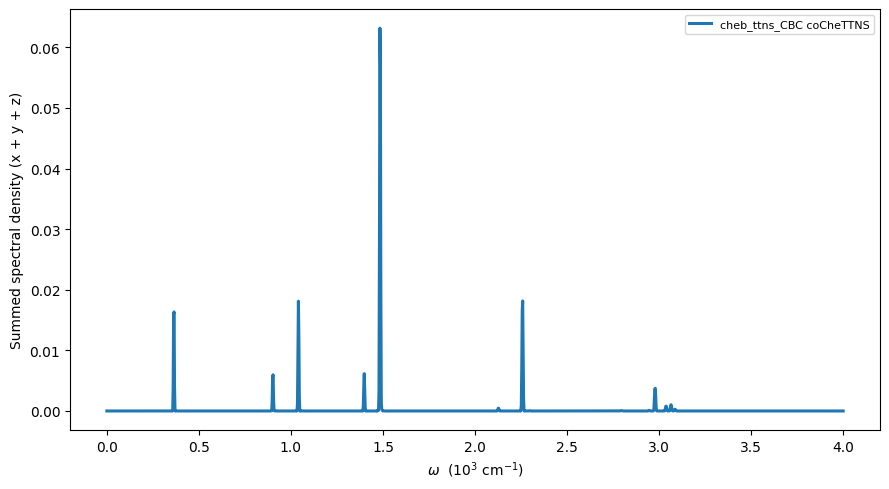

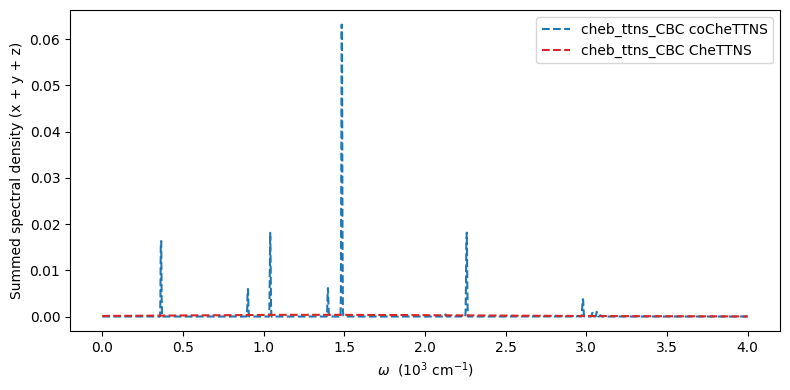

In [644]:
E_MAX_PLOT = 4.0
W_prime = RESCALE_W_PRIME
x_max = E_MAX_PLOT / a - W_prime
x_grid = np.linspace(-W_prime, min(0.999, x_max), N_ENERGY_GRID)
E_grid = a * (x_grid + W_prime)

# CBC-only notebook: no cached CBC spectrum is loaded here; CBC is recomputed above.
spectrum_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "spectrum reconstruction"
    tic = time.perf_counter()
    try:
        if data.get("cached_from") and "vals_ttns_eff" in data:
            vals_ttns_eff = np.asarray(data["vals_ttns_eff"], dtype=np.float64)
            data["timings"]["spectrum_s"] = 0.0
            spectrum_summary_rows.append({
                "method": data["label"],
                "status": data["status"],
                "spectrum_s": data["timings"]["spectrum_s"],
                "max_eff": float(np.max(vals_ttns_eff.real)),
                "min_eff": float(np.min(vals_ttns_eff.real)),
            })
            continue

        vals_ttns_by_component = {}
        for component in DIPOLE_COMPONENTS:
            vals_ttns_by_component[component] = np.array([
                reconstruct_delta_spectrum(x=x, mu=data["mu_by_component"][component], a=a)
                for x in x_grid
            ])
        vals_ttns = np.sum([vals_ttns_by_component[component] for component in DIPOLE_COMPONENTS], axis=0)

        vals_ttns_eff_by_component = {}
        for component in DIPOLE_COMPONENTS:
            vals_ttns_eff_by_component[component] = np.array([
                reconstruct_delta_spectrum(x=x, mu=data["mu_eff_by_component"][component], a=a)
                for x in x_grid
            ])
        vals_ttns_eff = np.sum([vals_ttns_eff_by_component[component] for component in DIPOLE_COMPONENTS], axis=0)

        data["vals_ttns_by_component"] = vals_ttns_by_component
        data["vals_ttns"] = vals_ttns
        data["vals_ttns_eff_by_component"] = vals_ttns_eff_by_component
        data["vals_ttns_eff"] = vals_ttns_eff
        data["timings"]["spectrum_s"] = time.perf_counter() - tic
        spectrum_summary_rows.append({
            "method": data["label"],
            "status": data["status"],
            "spectrum_s": data["timings"]["spectrum_s"],
            "max_eff": float(np.max(np.asarray(vals_ttns_eff).real)),
            "min_eff": float(np.min(np.asarray(vals_ttns_eff).real)),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        spectrum_summary_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    spectrum_summary_rows,
    ["method", "status", "spectrum_s", "max_eff", "min_eff"],
    title="Spectrum reconstruction summary",
)

reference_data = contraction_data.get(REFERENCE_METHOD)
if reference_data is None or reference_data.get("status") != "ok" or "vals_ttns_eff" not in reference_data:
    reference_data = next((data for _, data in active_method_items(contraction_data) if "vals_ttns_eff" in data), None)

comparison_rows = []
if reference_data is not None:
    ref_vals = np.asarray(reference_data["vals_ttns_eff"], dtype=np.float64)
    ref_norm = max(float(np.linalg.norm(ref_vals)), 1e-300)
    for method_key, data in active_method_items(contraction_data):
        if "vals_ttns_eff" not in data:
            continue
        vals = np.asarray(data["vals_ttns_eff"], dtype=np.float64)
        diff = vals - ref_vals
        cheb_vector_s = cheb_vector_runtime_s(data)
        heff_s = heff_runtime_s(data)
        cheb_plus_heff_s = cheb_vector_plus_heff_runtime_s(data)
        comparison_rows.append({
            "method": data["label"],
            "reference": reference_data["label"],
            "cheb_vector_s": cheb_vector_s,
            "heff_s": heff_s,
            "cheb_plus_heff_s": cheb_plus_heff_s,
            "mean_component_s": data.get("timings", {}).get("cheb_vector_build_mean_s", np.nan),
            "vectors_each": CHEB_TTNS_BASIS_SIZE,
            "rel_l2_vs_ref": float(np.linalg.norm(diff) / ref_norm),
            "max_abs_vs_ref": float(np.max(np.abs(diff))),
            "mean_abs_vs_ref": float(np.mean(np.abs(diff))),
        })

format_table(
    comparison_rows,
    ["method", "reference", "cheb_vector_s", "heff_s", "cheb_plus_heff_s", "mean_component_s", "vectors_each", "rel_l2_vs_ref", "max_abs_vs_ref", "mean_abs_vs_ref"],
    title="Contraction method comparison vs reference spectrum (time = 125 Chebyshev vectors + Heff)",
)

plt.figure(figsize=(9, 5))
for method_key, data in active_method_items(contraction_data):
    if "vals_ttns_eff" not in data:
        continue
    linewidth = 2.2 if data is reference_data else 1.1
    linestyle = "-" if data is reference_data else "--"
    plt.plot(E_grid, data["vals_ttns_eff"], linewidth=linewidth, linestyle=linestyle, label=f"{data['label']} coCheTTNS")
plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
plt.ylabel("Summed spectral density (x + y + z)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

if reference_data is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(E_grid, reference_data["vals_ttns_eff"], color="tab:blue", linestyle="--", label=f"{reference_data['label']} coCheTTNS")
    plt.plot(E_grid, reference_data["vals_ttns"], color="tab:red", linestyle="--", label=f"{reference_data['label']} CheTTNS")
    plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
    plt.ylabel("Summed spectral density (x + y + z)")
    plt.legend()
    plt.tight_layout()
    plt.show()


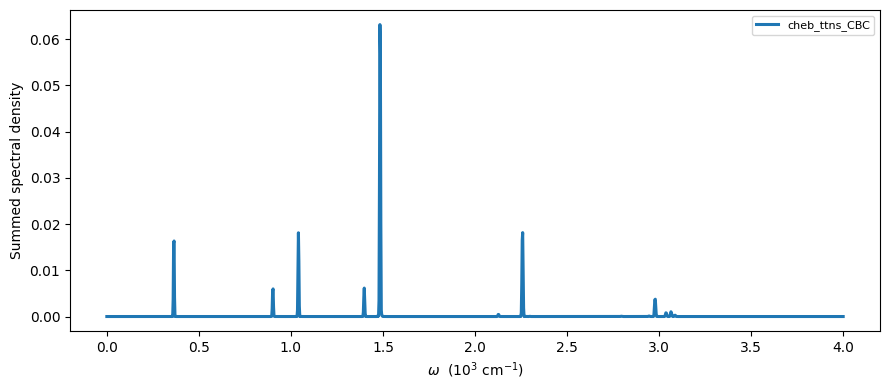

In [645]:
# Plot the summed x/y/z coCheTTNS spectrum for each contraction method.
plt.figure(figsize=(9, 4))
for method_key, data in active_method_items(contraction_data):
    if "vals_ttns_eff" not in data:
        continue
    linewidth = 2.2 if data is reference_data else 1.1
    plt.plot(
        E_grid,
        np.asarray(data["vals_ttns_eff"], dtype=np.float64),
        linewidth=linewidth,
        label=data["label"],
    )
plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
plt.ylabel("Summed spectral density")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Summed x/y/z peak area analysis



Visible broadened maxima for cheb_ttns_CBC (x + y + z)
peak  peak_E    height       left      right     grid_area    two_grid_area
----  --------  -----------  --------  --------  -----------  -------------
1     0.365228  0.0163459    0         0.537836  0.000100986  0.000201972  
2     0.903064  0.00597513   0.537836  0.933083  3.9011e-05   7.80221e-05  
3     1.04065   0.0181212    0.933083  1.22076   0.000109841  0.000219682  
4     1.39837   0.0061554    1.22076   1.42589   3.93385e-05  7.86769e-05  
5     1.48343   0.0631747    1.42589   1.81363   0.000437103  0.000874206  
6     2.12633   0.000459193  1.81363   2.18637   3.50564e-06  7.01127e-06  
7     2.25891   0.0181584    2.18637   2.5666    0.000135877  0.000271754  
8     2.97936   0.00374225   2.5666    3.00688   3.19458e-05  6.38916e-05  
9     3.0369    0.000798036  3.00688   3.0469    6.4783e-06   1.29566e-05  
10    3.06442   0.00102631   3.0469    4         1.04918e-05  2.09836e-05  

Peak area summary by contractio

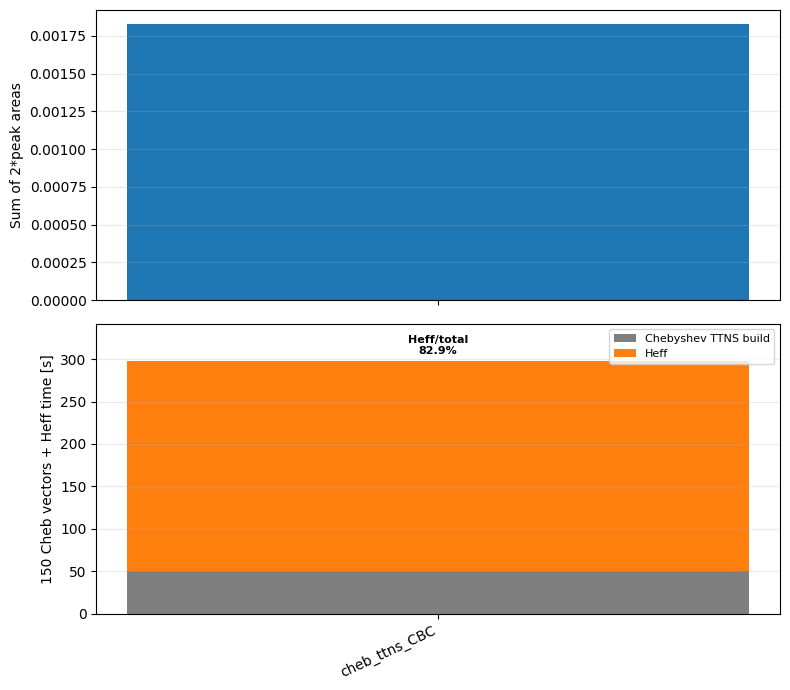

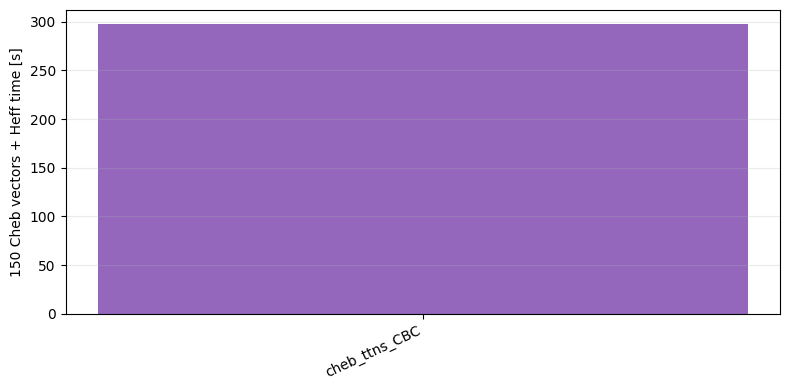


Peak comparison vs reference contraction method
method         reference      match  ref_peak  peak  ref_peak_E  peak_E    delta_peak_E  ref_two_area  two_area     delta_two_area  ratio_area
-------------  -------------  -----  --------  ----  ----------  --------  ------------  ------------  -----------  --------------  ----------
cheb_ttns_CBC  cheb_ttns_CBC  1      1         1     0.365228    0.365228  0             0.000201972   0.000201972  0               1         
cheb_ttns_CBC  cheb_ttns_CBC  2      2         2     0.903064    0.903064  0             7.80221e-05   7.80221e-05  0               1         
cheb_ttns_CBC  cheb_ttns_CBC  3      3         3     1.04065     1.04065   0             0.000219682   0.000219682  0               1         
cheb_ttns_CBC  cheb_ttns_CBC  4      4         4     1.39837     1.39837   0             7.86769e-05   7.86769e-05  0               1         
cheb_ttns_CBC  cheb_ttns_CBC  5      5         5     1.48343     1.48343   0             0.00

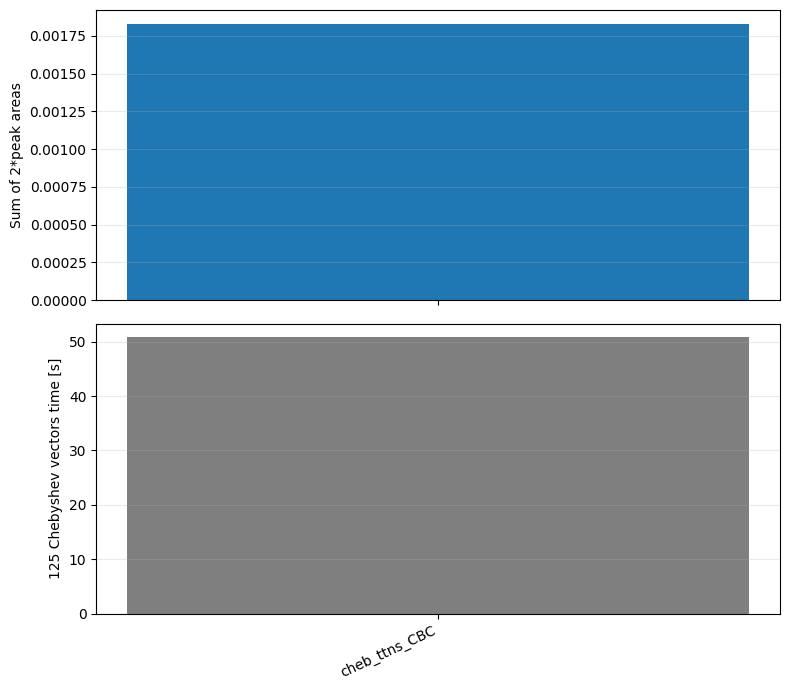

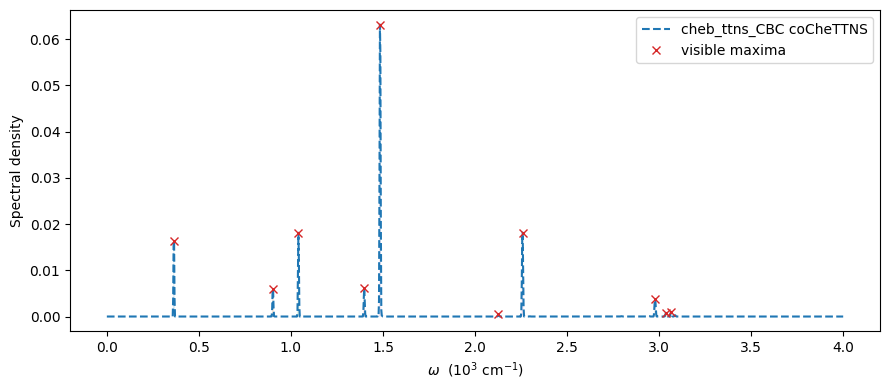

In [646]:
# Detect visible broadened maxima and integrate local areas of the summed
# spectrum vals_x + vals_y + vals_z for every contraction method.
PEAK_PROMINENCE_REL = 0.005
PEAK_MIN_DISTANCE = 0.015  # in 10^3 cm^-1 units
PEAK_MATCH_TOLERANCE = 0.08  # in 10^3 cm^-1 units


def detect_visible_peak_areas(vals, energy_grid, label):
    vals_area = np.clip(np.asarray(vals, dtype=np.float64), 0.0, None)
    if np.max(vals_area) <= 0:
        raise RuntimeError(f"The summed coCheTTNS spectrum for {label} is non-positive on the plotting grid.")

    dE = float(np.mean(np.diff(energy_grid)))
    min_distance_points = max(1, int(round(PEAK_MIN_DISTANCE / max(dE, 1e-15))))
    prominence = PEAK_PROMINENCE_REL * float(np.max(vals_area))
    peak_idx, peak_props = find_peaks(vals_area, prominence=prominence, distance=min_distance_points)

    if len(peak_idx) == 0:
        raise RuntimeError(f"No peaks found for {label}. Lower PEAK_PROMINENCE_REL or check the spectrum plot.")

    peak_idx = peak_idx[np.argsort(energy_grid[peak_idx])]
    boundary_idx = [0]
    for left_peak, right_peak in zip(peak_idx[:-1], peak_idx[1:]):
        segment = vals_area[left_peak:right_peak + 1]
        boundary_idx.append(left_peak + int(np.argmin(segment)))
    boundary_idx.append(len(energy_grid) - 1)

    rows = []
    for i, pidx in enumerate(peak_idx):
        left_i = boundary_idx[i]
        right_i = boundary_idx[i + 1]
        if right_i <= left_i:
            right_i = min(left_i + 1, len(energy_grid) - 1)

        local_E = energy_grid[left_i:right_i + 1]
        local_vals = vals_area[left_i:right_i + 1]
        area = float(np.trapezoid(local_vals, local_E)) if len(local_E) >= 2 else np.nan
        rows.append({
            "peak": i + 1,
            "peak_E": float(energy_grid[pidx]),
            "height": float(vals_area[pidx]),
            "left": float(energy_grid[left_i]),
            "right": float(energy_grid[right_i]),
            "grid_area": area,
            "two_grid_area": 2.0 * area if np.isfinite(area) else np.nan,
        })

    return rows, boundary_idx, vals_area, prominence, min_distance_points


def match_peak_rows(reference_rows, method_rows, tolerance):
    candidates = []
    for i, ref_row in enumerate(reference_rows):
        for j, row in enumerate(method_rows):
            delta = abs(ref_row["peak_E"] - row["peak_E"])
            if delta <= tolerance:
                candidates.append((delta, i, j))
    candidates.sort(key=lambda item: item[0])

    used_ref = set()
    used_method = set()
    matches = []
    for delta, i, j in candidates:
        if i in used_ref or j in used_method:
            continue
        used_ref.add(i)
        used_method.add(j)
        matches.append((i, j, delta))
    matches.sort(key=lambda item: reference_rows[item[0]]["peak_E"])
    unmatched_ref = [i for i in range(len(reference_rows)) if i not in used_ref]
    unmatched_method = [j for j in range(len(method_rows)) if j not in used_method]
    return matches, unmatched_ref, unmatched_method

area_rows_by_method = {}
peak_diagnostics_by_method = {}
peak_summary_rows = []

for method_key, data in active_method_items(contraction_data):
    if "vals_ttns_eff" not in data:
        continue
    phase = "peak area analysis"
    try:
        rows, boundary_idx, vals_area, prominence, min_distance_points = detect_visible_peak_areas(
            data["vals_ttns_eff"],
            E_grid,
            data["label"],
        )
        area_rows_by_method[method_key] = rows
        peak_diagnostics_by_method[method_key] = {
            "boundary_idx": boundary_idx,
            "vals_area": vals_area,
            "prominence": prominence,
            "min_distance_points": min_distance_points,
        }
        total_two_area = float(np.nansum([row["two_grid_area"] for row in rows]))
        peak_summary_rows.append({
            "method": data["label"],
            "peaks": len(rows),
            "sum_two_area": total_two_area,
            "prominence": prominence,
            "min_distance_points": min_distance_points,
        })
        print(f"\nVisible broadened maxima for {data['label']} (x + y + z)")
        format_table(rows, ["peak", "peak_E", "height", "left", "right", "grid_area", "two_grid_area"])
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    peak_summary_rows,
    ["method", "peaks", "sum_two_area", "prominence", "min_distance_points"],
    title="Peak area summary by contraction method",
)

reference_key = REFERENCE_METHOD if REFERENCE_METHOD in area_rows_by_method else next(iter(area_rows_by_method), None)
peak_comparison_rows = []
if reference_key is not None:
    ref_rows = area_rows_by_method[reference_key]
    ref_label = contraction_data[reference_key]["label"]
    for method_key, rows in area_rows_by_method.items():
        matches, unmatched_ref, unmatched_method = match_peak_rows(ref_rows, rows, PEAK_MATCH_TOLERANCE)
        for match_index, (i, j, abs_delta_peak_E) in enumerate(matches, start=1):
            ref_row = ref_rows[i]
            row = rows[j]
            ref_area = ref_row["two_grid_area"]
            area = row["two_grid_area"]
            peak_comparison_rows.append({
                "method": contraction_data[method_key]["label"],
                "reference": ref_label,
                "match": match_index,
                "ref_peak": ref_row["peak"],
                "peak": row["peak"],
                "ref_peak_E": ref_row["peak_E"],
                "peak_E": row["peak_E"],
                "delta_peak_E": row["peak_E"] - ref_row["peak_E"],
                "ref_two_area": ref_area,
                "two_area": area,
                "delta_two_area": area - ref_area,
                "ratio_area": area / ref_area if ref_area != 0 else np.nan,
            })
        if unmatched_ref:
            print(f"Unmatched reference peaks for {contraction_data[method_key]['label']}:", unmatched_ref)
        if unmatched_method:
            print(f"Unmatched method peaks for {contraction_data[method_key]['label']}:", unmatched_method)

format_table(
    peak_comparison_rows,
    ["method", "reference", "match", "ref_peak", "peak", "ref_peak_E", "peak_E", "delta_peak_E", "ref_two_area", "two_area", "delta_two_area", "ratio_area"],
    title="Peak comparison vs reference contraction method",
)

if peak_summary_rows:
    plot_method_keys = [
        method_key
        for method_key, data in active_method_items(contraction_data)
        if method_key in area_rows_by_method
    ]
    method_labels = [contraction_data[method_key]["label"] for method_key in plot_method_keys]
    total_areas = np.array([
        np.nansum([row["two_grid_area"] for row in area_rows_by_method[method_key]])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    cheb_runtimes = np.array([
        cheb_vector_runtime_s(contraction_data[method_key])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    heff_runtimes = np.array([
        heff_runtime_s(contraction_data[method_key])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    runtimes_with_heff = cheb_runtimes + heff_runtimes
    heff_runtime_fraction = np.divide(
        heff_runtimes,
        runtimes_with_heff,
        out=np.full_like(heff_runtimes, np.nan),
        where=runtimes_with_heff > 0.0,
    )
    x = np.arange(len(method_labels))

    fig, (ax_area, ax_time) = plt.subplots(2, 1, figsize=(max(8, 1.2 * len(method_labels)), 7), sharex=True)
    ax_area.bar(x, total_areas, width=0.6)
    ax_area.set_ylabel("Sum of 2*peak areas")
    ax_area.grid(True, axis="y", alpha=0.25)

    ax_time.bar(x, cheb_runtimes, width=0.6, color="tab:gray", label="Chebyshev TTNS build")
    ax_time.bar(x, heff_runtimes, width=0.6, bottom=cheb_runtimes, color="tab:orange", label="Heff")
    if np.any(np.isfinite(runtimes_with_heff)):
        label_pad = 0.02 * float(np.nanmax(runtimes_with_heff))
        for x_pos, total_s, fraction in zip(x, runtimes_with_heff, heff_runtime_fraction):
            if not np.isfinite(total_s) or not np.isfinite(fraction):
                continue
            ax_time.text(
                x_pos,
                total_s + label_pad,
                f"Heff/total\n{fraction:.1%}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="semibold",
            )
        ax_time.set_ylim(top=float(np.nanmax(runtimes_with_heff)) * 1.15)
    ax_time.set_ylabel("150 Cheb vectors + Heff time [s]")
    ax_time.set_xticks(x)
    ax_time.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time.grid(True, axis="y", alpha=0.25)
    ax_time.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    fig_time, ax_time_total = plt.subplots(figsize=(max(8, 1.2 * len(method_labels)), 4))
    ax_time_total.bar(x, runtimes_with_heff, width=0.6, color="tab:purple")
    ax_time_total.set_ylabel("150 Cheb vectors + Heff time [s]")
    ax_time_total.set_xticks(x)
    ax_time_total.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time_total.grid(True, axis="y", alpha=0.25)
    fig_time.tight_layout()
    plt.show()

if reference_key is not None:
    ref_rows = area_rows_by_method[reference_key]
    ref_label = contraction_data[reference_key]["label"]
    for method_key, rows in area_rows_by_method.items():
        matches, unmatched_ref, unmatched_method = match_peak_rows(ref_rows, rows, PEAK_MATCH_TOLERANCE)
        for match_index, (i, j, abs_delta_peak_E) in enumerate(matches, start=1):
            ref_row = ref_rows[i]
            row = rows[j]
            ref_area = ref_row["two_grid_area"]
            area = row["two_grid_area"]
            peak_comparison_rows.append({
                "method": contraction_data[method_key]["label"],
                "reference": ref_label,
                "match": match_index,
                "ref_peak": ref_row["peak"],
                "peak": row["peak"],
                "ref_peak_E": ref_row["peak_E"],
                "peak_E": row["peak_E"],
                "delta_peak_E": row["peak_E"] - ref_row["peak_E"],
                "ref_two_area": ref_area,
                "two_area": area,
                "delta_two_area": area - ref_area,
                "ratio_area": area / ref_area if ref_area != 0 else np.nan,
            })
        if unmatched_ref:
            print(f"Unmatched reference peaks for {contraction_data[method_key]['label']}:", unmatched_ref)
        if unmatched_method:
            print(f"Unmatched method peaks for {contraction_data[method_key]['label']}:", unmatched_method)

format_table(
    peak_comparison_rows,
    ["method", "reference", "match", "ref_peak", "peak", "ref_peak_E", "peak_E", "delta_peak_E", "ref_two_area", "two_area", "delta_two_area", "ratio_area"],
    title="Peak comparison vs reference contraction method",
)

if peak_summary_rows:
    method_labels = [row["method"] for row in peak_summary_rows]
    total_areas = np.array([row["sum_two_area"] for row in peak_summary_rows], dtype=np.float64)
    runtimes = []
    for method_key, data in active_method_items(contraction_data):
        if method_key in area_rows_by_method:
            runtimes.append(cheb_vector_runtime_s(data))
    x = np.arange(len(method_labels))

    fig, (ax_area, ax_time) = plt.subplots(2, 1, figsize=(max(8, 1.2 * len(method_labels)), 7), sharex=True)
    ax_area.bar(x, total_areas, width=0.6)
    ax_area.set_ylabel("Sum of 2*peak areas")
    ax_area.grid(True, axis="y", alpha=0.25)

    ax_time.bar(x, runtimes, width=0.6, color="tab:gray")
    ax_time.set_ylabel("125 Chebyshev vectors time [s]")
    ax_time.set_xticks(x)
    ax_time.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

if reference_key is not None:
    ref_diag = peak_diagnostics_by_method[reference_key]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(E_grid, ref_diag["vals_area"], color="tab:blue", linestyle="--", label=f"{contraction_data[reference_key]['label']} coCheTTNS")
    for left_i, right_i in zip(ref_diag["boundary_idx"][:-1], ref_diag["boundary_idx"][1:]):
        ax.fill_between(E_grid[left_i:right_i + 1], ref_diag["vals_area"][left_i:right_i + 1], alpha=0.16)
    ax.plot(
        [row["peak_E"] for row in area_rows_by_method[reference_key]],
        [row["height"] for row in area_rows_by_method[reference_key]],
        "x",
        color="tab:red",
        label="visible maxima",
    )
    ax.set_xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
    ax.set_ylabel("Spectral density")
    ax.legend()
    fig.tight_layout()
    plt.show()


### Final method status


In [647]:
status_rows = []
for method_key, data in contraction_data.items():
    timings = data.get("timings", {})
    cheb_vector_s = cheb_vector_runtime_s(data)
    heff_s = heff_runtime_s(data)
    status_rows.append({
        "method": data["label"],
        "status": data.get("status", "unknown"),
        "cheb_vector_s": cheb_vector_s,
        "heff_s": heff_s,
        "cheb_plus_heff_s": cheb_vector_s + heff_s,
        "mean_component_s": timings.get("cheb_vector_build_mean_s", np.nan),
        "vectors_each": CHEB_TTNS_BASIS_SIZE,
        "vectors_total": data.get("cheb_vectors_total", np.nan),
        "Hpsin_total_s": timings.get("cheb_Hpsin_total_s", np.nan),
        "postprocess_total_s": timings.get("cheb_postprocess_total_s", np.nan),
        "psi_np1_total_s": timings.get("cheb_psi_np1_total_s", np.nan),
        "error": data.get("error", ""),
    })

format_table(
    status_rows,
    [
        "method",
        "status",
        "cheb_vector_s",
        "heff_s",
        "cheb_plus_heff_s",
        "mean_component_s",
        "vectors_each",
        "vectors_total",
        "Hpsin_total_s",
        "postprocess_total_s",
        "psi_np1_total_s",
        "error",
    ],
    title="Final contraction method status (time = full Chebyshev TTNS build + Heff)",
)

failed = [data for data in contraction_data.values() if data.get("status") != "ok"]
if failed:
    print("\nFailed method tracebacks are stored in contraction_data[method_key]['traceback'].")



Final contraction method status (time = full Chebyshev TTNS build + Heff)
method         status  cheb_vector_s  heff_s  cheb_plus_heff_s  mean_component_s  vectors_each  vectors_total  Hpsin_total_s  postprocess_total_s  psi_np1_total_s  error
-------------  ------  -------------  ------  ----------------  ----------------  ------------  -------------  -------------  -------------------  ---------------  -----
cheb_ttns_CBC  ok      50.7736        246.47  297.243           16.9245           125           375            48.6466        0.0127202            2.11124               


### Dipole spectral function


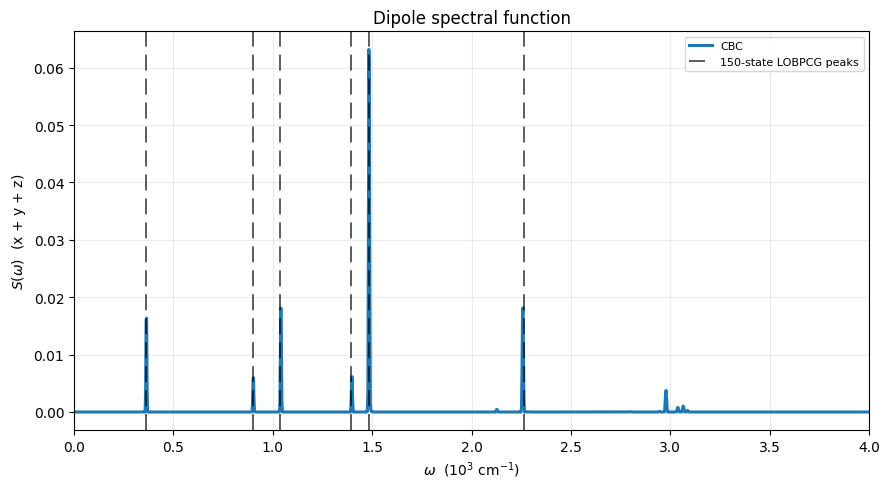

150-state LOBPCG peak markers used:
  0.360998 (states 1-2)
  0.900673 (states 6)
  1.034171 (states 7-8)
  1.392940 (states 15,19)
  1.483172 (states 25-26)
  2.264723 (states 84)
Saved spectral figures: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.pdf and /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.png


In [648]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
REFERENCE_AREA_CSV = REFERENCE_DIR / "lobpcg_150_final_ir_merged_delta_pole_areas.csv"
REFERENCE_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
SPECTRUM_NPZ = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_RESULT_DIR.mkdir(parents=True, exist_ok=True)
METHOD = "cheb_ttns_CBC"
METHOD_LABEL = "CBC"
METHOD_COLOR = "tab:blue"
IR_INTENSITY_FACTOR = 2.50664
AU_DIPOLE_TO_DEBYE = 2.541746473
PEAK_MATCH_TOLERANCE = 0.08
PEAK_PROMINENCE_REL = 0.005
PEAK_MIN_DISTANCE = 0.015


def _read_csv_rows(path):
    with Path(path).open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _reference_area_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_AREA_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_two_area": float(row["2*Omega_sum"]),
        })
    return rows


def _reference_ir_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_IR_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_A_IR_km_mol": float(row["A_IR_km_mol"]),
        })
    return rows


def _cached_spectrum():
    data = None
    if "contraction_data" in globals():
        data = (
            contraction_data.get("cbc")
            or contraction_data.get(METHOD)
            or contraction_data.get("cheb_ttns_CBC")
        )
    if data is not None and "E_grid" in globals():
        values = data.get("vals_ttns_eff")
        if values is None:
            values = data.get("vals_ttns")
        if values is not None:
            energy_grid = np.asarray(E_grid, dtype=np.float64)
            values = np.real_if_close(np.asarray(values), tol=1000).astype(np.float64)
            if energy_grid.shape != values.shape:
                raise ValueError(
                    f"Current kernel spectrum length {values.size} does not match "
                    f"E_grid length {energy_grid.size}."
                )
            _cached_spectrum.source = "current kernel spectrum: contraction_data['cbc']['vals_ttns_eff']"
            return energy_grid, values

    with np.load(SPECTRUM_NPZ) as spectrum:
        _cached_spectrum.source = f"cached spectrum file: {SPECTRUM_NPZ}"
        return np.asarray(spectrum["energy_1000_cm"], dtype=np.float64), np.asarray(spectrum["CBC"], dtype=np.float64)


def _peak_rows():
    energy_grid, values = _cached_spectrum()
    vals_area = np.clip(values, 0.0, None)
    dE = float(np.mean(np.diff(energy_grid)))
    distance_points = max(1, int(round(PEAK_MIN_DISTANCE / max(dE, 1e-15))))
    prominence = PEAK_PROMINENCE_REL * float(np.max(vals_area))
    peak_idx, _ = find_peaks(vals_area, prominence=prominence, distance=distance_points)
    peak_idx = peak_idx[np.argsort(energy_grid[peak_idx])]
    boundary_idx = [0]
    for left_peak, right_peak in zip(peak_idx[:-1], peak_idx[1:]):
        segment = vals_area[left_peak:right_peak + 1]
        boundary_idx.append(left_peak + int(np.argmin(segment)))
    boundary_idx.append(len(energy_grid) - 1)
    rows = []
    for index, pidx in enumerate(peak_idx):
        left_i = boundary_idx[index]
        right_i = boundary_idx[index + 1]
        area = float(np.trapezoid(vals_area[left_i:right_i + 1], energy_grid[left_i:right_i + 1]))
        rows.append({
            "peak": index + 1,
            "peak_E": float(energy_grid[pidx]),
            "height": float(vals_area[pidx]),
            "left": float(energy_grid[left_i]),
            "right": float(energy_grid[right_i]),
            "grid_area": area,
            "two_grid_area": 2.0 * area,
        })
    return rows


def _area_comparison_rows():
    peak_rows = _peak_rows()
    rows = []
    used = set()
    for ref in _reference_area_rows():
        candidates = []
        for index, row in enumerate(peak_rows):
            if index in used:
                continue
            delta = abs(float(row["peak_E"]) - float(ref["peak_E"]))
            if delta <= PEAK_MATCH_TOLERANCE:
                candidates.append((delta, index, row))
        if not candidates:
            rows.append({
                "method": METHOD,
                "lobpcg_peak": ref["lobpcg_peak"],
                "lobpcg_members": ref["lobpcg_members"],
                "reference_peak_E": ref["peak_E"],
                "cheb_peak": "missing",
                "cheb_peak_E": np.nan,
                "lobpcg_two_area": ref["lobpcg_two_area"],
                "cheb_two_area": np.nan,
                "delta_two_area": np.nan,
                "area_pct_error": np.nan,
            })
            continue
        _, index, row = min(candidates, key=lambda item: item[0])
        used.add(index)
        lobpcg_area = float(ref["lobpcg_two_area"])
        cheb_area = float(row["two_grid_area"])
        delta_area = cheb_area - lobpcg_area
        rows.append({
            "method": METHOD,
            "lobpcg_peak": ref["lobpcg_peak"],
            "lobpcg_members": ref["lobpcg_members"],
            "reference_peak_E": ref["peak_E"],
            "cheb_peak": row["peak"],
            "cheb_peak_E": row["peak_E"],
            "lobpcg_two_area": lobpcg_area,
            "cheb_two_area": cheb_area,
            "delta_two_area": delta_area,
            "area_pct_error": 100.0 * delta_area / lobpcg_area if lobpcg_area else np.nan,
        })
    return rows


def _ir_comparison_rows():
    reference_by_peak = {row["lobpcg_peak"]: row for row in _reference_ir_rows()}
    rows = []
    for area_row in _area_comparison_rows():
        ref = reference_by_peak.get(area_row["lobpcg_peak"])
        if ref is None:
            continue
        cheb_peak_E = _as_float(area_row["cheb_peak_E"])
        cheb_two_area = _as_float(area_row["cheb_two_area"])
        if np.isfinite(cheb_peak_E) and np.isfinite(cheb_two_area):
            cheb_ir = IR_INTENSITY_FACTOR * 1000.0 * cheb_peak_E * cheb_two_area * AU_DIPOLE_TO_DEBYE**2
        else:
            cheb_ir = np.nan
        lobpcg_ir = float(ref["lobpcg_A_IR_km_mol"])
        delta_ir = cheb_ir - lobpcg_ir if np.isfinite(cheb_ir) else np.nan
        rows.append({
            "method": area_row["method"],
            "lobpcg_peak": area_row["lobpcg_peak"],
            "lobpcg_members": area_row["lobpcg_members"],
            "reference_peak_E": area_row["reference_peak_E"],
            "cheb_peak": area_row["cheb_peak"],
            "cheb_peak_E": area_row["cheb_peak_E"],
            "lobpcg_A_IR_km_mol": lobpcg_ir,
            "cheb_A_IR_km_mol": cheb_ir,
            "delta_A_IR_km_mol": delta_ir,
            "ir_pct_error": 100.0 * delta_ir / lobpcg_ir if lobpcg_ir and np.isfinite(delta_ir) else np.nan,
        })
    return rows


def _format_table(rows, columns, title=None):
    if title:
        print("\n" + title)
    formatted = []
    for row in rows:
        item = {}
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, (float, np.floating)):
                value = f"{value:.6g}" if np.isfinite(value) else "nan"
            item[col] = str(value)
        formatted.append(item)
    widths = {col: max([len(col)] + [len(row[col]) for row in formatted]) for col in columns}
    fmt = "  ".join("{:<" + str(widths[col]) + "}" for col in columns)
    print(fmt.format(*columns))
    print(fmt.format(*["-" * widths[col] for col in columns]))
    for row in formatted:
        print(fmt.format(*[row[col] for col in columns]))

energy_grid, spectrum_values = _cached_spectrum()
reference_rows = _reference_area_rows()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(energy_grid, spectrum_values, linewidth=2.2, label=METHOD_LABEL, color=METHOD_COLOR)
for marker_index, row in enumerate(reference_rows):
    ax.axvline(
        float(row["peak_E"]),
        color="black",
        linestyle=(0, (10, 5)),
        linewidth=1.15,
        alpha=0.78,
        label="150-state LOBPCG peaks" if marker_index == 0 else "_nolegend_",
        zorder=3.0,
    )
ax.set_title("Dipole spectral function")
ax.set_xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
ax.set_ylabel(r"$S(\omega)$  (x + y + z)")
ax.set_xlim(0.0, 4.0)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.pdf", bbox_inches="tight")
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.png", dpi=220, bbox_inches="tight")
plt.show()

print("150-state LOBPCG peak markers used:")
for row in reference_rows:
    print(f"  {row['peak_E']:.6f} (states {row['lobpcg_members']})")
print("Saved spectral figures:", "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.pdf", "and", "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_dipole_spectral_function.png")


### Peak area errors vs LOBPCG reference



LOBPCG area reference
lobpcg_peak  lobpcg_members  lobpcg_two_area
-----------  --------------  ---------------
0.361        1-2             0.000200921    
0.901        6               7.73129e-05    
1.034        7-8             0.000217306    
1.393        15,19           7.84123e-05    
1.483        25-26           0.000877563    
2.265        84              0.000277808    

Chebyshev peak area error vs LOBPCG
method         lobpcg_peak  lobpcg_members  cheb_peak  cheb_peak_E  lobpcg_two_area  cheb_two_area  delta_two_area  area_pct_error
-------------  -----------  --------------  ---------  -----------  ---------------  -------------  --------------  --------------
cheb_ttns_CBC  0.361        1-2             1          0.365228     0.000200921      0.000201972    1.05102e-06     0.5231        
cheb_ttns_CBC  0.901        6               2          0.903064     7.73129e-05      7.80221e-05    7.09218e-07     0.917336      
cheb_ttns_CBC  1.034        7-8             3          1

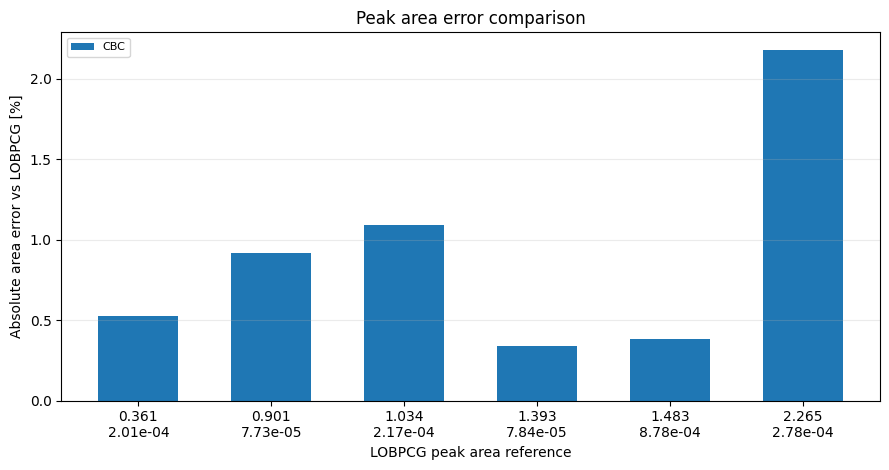

In [649]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
REFERENCE_AREA_CSV = REFERENCE_DIR / "lobpcg_150_final_ir_merged_delta_pole_areas.csv"
REFERENCE_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
SPECTRUM_NPZ = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_RESULT_DIR.mkdir(parents=True, exist_ok=True)
METHOD = "cheb_ttns_CBC"
METHOD_LABEL = "CBC"
METHOD_COLOR = "tab:blue"
IR_INTENSITY_FACTOR = 2.50664
AU_DIPOLE_TO_DEBYE = 2.541746473
PEAK_MATCH_TOLERANCE = 0.08
PEAK_PROMINENCE_REL = 0.005
PEAK_MIN_DISTANCE = 0.015


def _read_csv_rows(path):
    with Path(path).open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _reference_area_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_AREA_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_two_area": float(row["2*Omega_sum"]),
        })
    return rows


def _reference_ir_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_IR_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_A_IR_km_mol": float(row["A_IR_km_mol"]),
        })
    return rows


def _cached_spectrum():
    data = None
    if "contraction_data" in globals():
        data = (
            contraction_data.get("cbc")
            or contraction_data.get(METHOD)
            or contraction_data.get("cheb_ttns_CBC")
        )
    if data is not None and "E_grid" in globals():
        values = data.get("vals_ttns_eff")
        if values is None:
            values = data.get("vals_ttns")
        if values is not None:
            energy_grid = np.asarray(E_grid, dtype=np.float64)
            values = np.real_if_close(np.asarray(values), tol=1000).astype(np.float64)
            if energy_grid.shape != values.shape:
                raise ValueError(
                    f"Current kernel spectrum length {values.size} does not match "
                    f"E_grid length {energy_grid.size}."
                )
            _cached_spectrum.source = "current kernel spectrum: contraction_data['cbc']['vals_ttns_eff']"
            return energy_grid, values

    with np.load(SPECTRUM_NPZ) as spectrum:
        _cached_spectrum.source = f"cached spectrum file: {SPECTRUM_NPZ}"
        return np.asarray(spectrum["energy_1000_cm"], dtype=np.float64), np.asarray(spectrum["CBC"], dtype=np.float64)


def _peak_rows():
    energy_grid, values = _cached_spectrum()
    vals_area = np.clip(values, 0.0, None)
    dE = float(np.mean(np.diff(energy_grid)))
    distance_points = max(1, int(round(PEAK_MIN_DISTANCE / max(dE, 1e-15))))
    prominence = PEAK_PROMINENCE_REL * float(np.max(vals_area))
    peak_idx, _ = find_peaks(vals_area, prominence=prominence, distance=distance_points)
    peak_idx = peak_idx[np.argsort(energy_grid[peak_idx])]
    boundary_idx = [0]
    for left_peak, right_peak in zip(peak_idx[:-1], peak_idx[1:]):
        segment = vals_area[left_peak:right_peak + 1]
        boundary_idx.append(left_peak + int(np.argmin(segment)))
    boundary_idx.append(len(energy_grid) - 1)
    rows = []
    for index, pidx in enumerate(peak_idx):
        left_i = boundary_idx[index]
        right_i = boundary_idx[index + 1]
        area = float(np.trapezoid(vals_area[left_i:right_i + 1], energy_grid[left_i:right_i + 1]))
        rows.append({
            "peak": index + 1,
            "peak_E": float(energy_grid[pidx]),
            "height": float(vals_area[pidx]),
            "left": float(energy_grid[left_i]),
            "right": float(energy_grid[right_i]),
            "grid_area": area,
            "two_grid_area": 2.0 * area,
        })
    return rows


def _area_comparison_rows():
    peak_rows = _peak_rows()
    rows = []
    used = set()
    for ref in _reference_area_rows():
        candidates = []
        for index, row in enumerate(peak_rows):
            if index in used:
                continue
            delta = abs(float(row["peak_E"]) - float(ref["peak_E"]))
            if delta <= PEAK_MATCH_TOLERANCE:
                candidates.append((delta, index, row))
        if not candidates:
            rows.append({
                "method": METHOD,
                "lobpcg_peak": ref["lobpcg_peak"],
                "lobpcg_members": ref["lobpcg_members"],
                "reference_peak_E": ref["peak_E"],
                "cheb_peak": "missing",
                "cheb_peak_E": np.nan,
                "lobpcg_two_area": ref["lobpcg_two_area"],
                "cheb_two_area": np.nan,
                "delta_two_area": np.nan,
                "area_pct_error": np.nan,
            })
            continue
        _, index, row = min(candidates, key=lambda item: item[0])
        used.add(index)
        lobpcg_area = float(ref["lobpcg_two_area"])
        cheb_area = float(row["two_grid_area"])
        delta_area = cheb_area - lobpcg_area
        rows.append({
            "method": METHOD,
            "lobpcg_peak": ref["lobpcg_peak"],
            "lobpcg_members": ref["lobpcg_members"],
            "reference_peak_E": ref["peak_E"],
            "cheb_peak": row["peak"],
            "cheb_peak_E": row["peak_E"],
            "lobpcg_two_area": lobpcg_area,
            "cheb_two_area": cheb_area,
            "delta_two_area": delta_area,
            "area_pct_error": 100.0 * delta_area / lobpcg_area if lobpcg_area else np.nan,
        })
    return rows


def _ir_comparison_rows():
    reference_by_peak = {row["lobpcg_peak"]: row for row in _reference_ir_rows()}
    rows = []
    for area_row in _area_comparison_rows():
        ref = reference_by_peak.get(area_row["lobpcg_peak"])
        if ref is None:
            continue
        cheb_peak_E = _as_float(area_row["cheb_peak_E"])
        cheb_two_area = _as_float(area_row["cheb_two_area"])
        if np.isfinite(cheb_peak_E) and np.isfinite(cheb_two_area):
            cheb_ir = IR_INTENSITY_FACTOR * 1000.0 * cheb_peak_E * cheb_two_area * AU_DIPOLE_TO_DEBYE**2
        else:
            cheb_ir = np.nan
        lobpcg_ir = float(ref["lobpcg_A_IR_km_mol"])
        delta_ir = cheb_ir - lobpcg_ir if np.isfinite(cheb_ir) else np.nan
        rows.append({
            "method": area_row["method"],
            "lobpcg_peak": area_row["lobpcg_peak"],
            "lobpcg_members": area_row["lobpcg_members"],
            "reference_peak_E": area_row["reference_peak_E"],
            "cheb_peak": area_row["cheb_peak"],
            "cheb_peak_E": area_row["cheb_peak_E"],
            "lobpcg_A_IR_km_mol": lobpcg_ir,
            "cheb_A_IR_km_mol": cheb_ir,
            "delta_A_IR_km_mol": delta_ir,
            "ir_pct_error": 100.0 * delta_ir / lobpcg_ir if lobpcg_ir and np.isfinite(delta_ir) else np.nan,
        })
    return rows


def _format_table(rows, columns, title=None):
    if title:
        print("\n" + title)
    formatted = []
    for row in rows:
        item = {}
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, (float, np.floating)):
                value = f"{value:.6g}" if np.isfinite(value) else "nan"
            item[col] = str(value)
        formatted.append(item)
    widths = {col: max([len(col)] + [len(row[col]) for row in formatted]) for col in columns}
    fmt = "  ".join("{:<" + str(widths[col]) + "}" for col in columns)
    print(fmt.format(*columns))
    print(fmt.format(*["-" * widths[col] for col in columns]))
    for row in formatted:
        print(fmt.format(*[row[col] for col in columns]))

reference_rows = _reference_area_rows()
lobpcg_area_comparison_rows = _area_comparison_rows()
_format_table(reference_rows, ["lobpcg_peak", "lobpcg_members", "lobpcg_two_area"], title="LOBPCG area reference")
_format_table(
    lobpcg_area_comparison_rows,
    ["method", "lobpcg_peak", "lobpcg_members", "cheb_peak", "cheb_peak_E", "lobpcg_two_area", "cheb_two_area", "delta_two_area", "area_pct_error"],
    title="Chebyshev peak area error vs LOBPCG",
)

with (CBC_RESULT_DIR / "lobpcg_area_comparison.csv").open("w", newline="") as handle:
    fieldnames = ["method", "lobpcg_peak", "lobpcg_members", "reference_peak_E", "cheb_peak", "cheb_peak_E", "lobpcg_two_area", "cheb_two_area", "delta_two_area", "area_pct_error"]
    writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(lobpcg_area_comparison_rows)

x = np.arange(len(reference_rows), dtype=np.float64)
fig, ax = plt.subplots(figsize=(max(9, 1.35 * len(reference_rows)), 4.8))
ax.bar(x, [abs(_as_float(row["area_pct_error"])) for row in lobpcg_area_comparison_rows], width=0.6, color=METHOD_COLOR, label=METHOD_LABEL)
ax.set_ylabel("Absolute area error vs LOBPCG [%]")
ax.set_xlabel("LOBPCG peak area reference")
ax.set_title("Peak area error comparison")
ax.set_xticks(x)
ax.set_xticklabels([f"{row['lobpcg_peak']}\n{row['lobpcg_two_area']:.2e}" for row in reference_rows])
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_area_error.pdf", bbox_inches="tight")
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_area_error.png", dpi=220, bbox_inches="tight")
plt.show()


### Integrated IR intensity errors vs LOBPCG reference



LOBPCG IR intensity reference
lobpcg_peak  lobpcg_members  lobpcg_A_IR_km_mol
-----------  --------------  ------------------
0.361        1-2             1.17459           
0.901        6               1.12765           
1.034        7-8             3.63932           
1.393        15,19           1.76878           
1.483        25-26           21.0779           
2.265        84              10.1886           

Chebyshev integrated IR intensity error vs LOBPCG
method         lobpcg_peak  cheb_peak  cheb_peak_E  lobpcg_A_IR_km_mol  cheb_A_IR_km_mol  delta_A_IR_km_mol  ir_pct_error
-------------  -----------  ---------  -----------  ------------------  ----------------  -----------------  ------------
cheb_ttns_CBC  0.361        1          0.365228     1.17459             1.19457           0.0199816          1.70116     
cheb_ttns_CBC  0.901        2          0.903064     1.12765             1.14102           0.0133659          1.18529     
cheb_ttns_CBC  1.034        3          1.04065

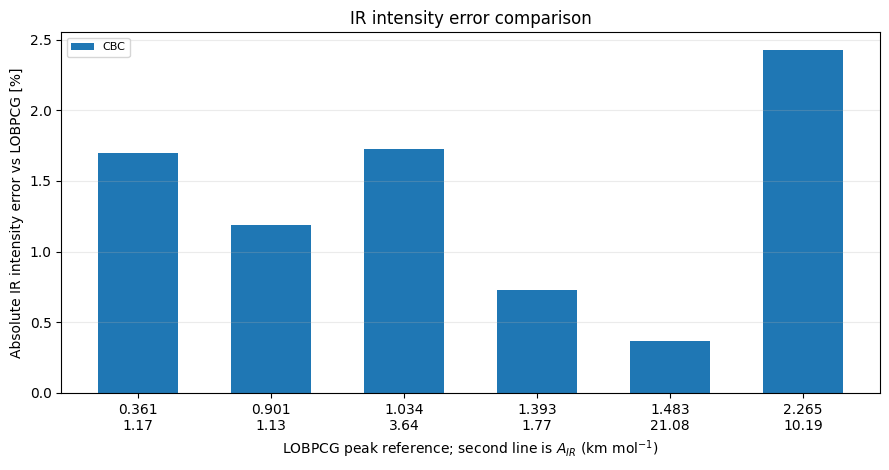

In [650]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
REFERENCE_AREA_CSV = REFERENCE_DIR / "lobpcg_150_final_ir_merged_delta_pole_areas.csv"
REFERENCE_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
SPECTRUM_NPZ = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_RESULT_DIR.mkdir(parents=True, exist_ok=True)
METHOD = "cheb_ttns_CBC"
METHOD_LABEL = "CBC"
METHOD_COLOR = "tab:blue"
IR_INTENSITY_FACTOR = 2.50664
AU_DIPOLE_TO_DEBYE = 2.541746473
PEAK_MATCH_TOLERANCE = 0.08
PEAK_PROMINENCE_REL = 0.005
PEAK_MIN_DISTANCE = 0.015


def _read_csv_rows(path):
    with Path(path).open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _reference_area_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_AREA_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_two_area": float(row["2*Omega_sum"]),
        })
    return rows


def _reference_ir_rows():
    rows = []
    for row in _read_csv_rows(REFERENCE_IR_CSV):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "lobpcg_members": row.get("rank_range") or row.get("initial_indices") or f"{peak_E:.3f}",
            "peak_E": peak_E,
            "lobpcg_A_IR_km_mol": float(row["A_IR_km_mol"]),
        })
    return rows


def _cached_spectrum():
    data = None
    if "contraction_data" in globals():
        data = (
            contraction_data.get("cbc")
            or contraction_data.get(METHOD)
            or contraction_data.get("cheb_ttns_CBC")
        )
    if data is not None and "E_grid" in globals():
        values = data.get("vals_ttns_eff")
        if values is None:
            values = data.get("vals_ttns")
        if values is not None:
            energy_grid = np.asarray(E_grid, dtype=np.float64)
            values = np.real_if_close(np.asarray(values), tol=1000).astype(np.float64)
            if energy_grid.shape != values.shape:
                raise ValueError(
                    f"Current kernel spectrum length {values.size} does not match "
                    f"E_grid length {energy_grid.size}."
                )
            _cached_spectrum.source = "current kernel spectrum: contraction_data['cbc']['vals_ttns_eff']"
            return energy_grid, values

    with np.load(SPECTRUM_NPZ) as spectrum:
        _cached_spectrum.source = f"cached spectrum file: {SPECTRUM_NPZ}"
        return np.asarray(spectrum["energy_1000_cm"], dtype=np.float64), np.asarray(spectrum["CBC"], dtype=np.float64)


def _peak_rows():
    energy_grid, values = _cached_spectrum()
    vals_area = np.clip(values, 0.0, None)
    dE = float(np.mean(np.diff(energy_grid)))
    distance_points = max(1, int(round(PEAK_MIN_DISTANCE / max(dE, 1e-15))))
    prominence = PEAK_PROMINENCE_REL * float(np.max(vals_area))
    peak_idx, _ = find_peaks(vals_area, prominence=prominence, distance=distance_points)
    peak_idx = peak_idx[np.argsort(energy_grid[peak_idx])]
    boundary_idx = [0]
    for left_peak, right_peak in zip(peak_idx[:-1], peak_idx[1:]):
        segment = vals_area[left_peak:right_peak + 1]
        boundary_idx.append(left_peak + int(np.argmin(segment)))
    boundary_idx.append(len(energy_grid) - 1)
    rows = []
    for index, pidx in enumerate(peak_idx):
        left_i = boundary_idx[index]
        right_i = boundary_idx[index + 1]
        area = float(np.trapezoid(vals_area[left_i:right_i + 1], energy_grid[left_i:right_i + 1]))
        rows.append({
            "peak": index + 1,
            "peak_E": float(energy_grid[pidx]),
            "height": float(vals_area[pidx]),
            "left": float(energy_grid[left_i]),
            "right": float(energy_grid[right_i]),
            "grid_area": area,
            "two_grid_area": 2.0 * area,
        })
    return rows


def _area_comparison_rows():
    peak_rows = _peak_rows()
    rows = []
    used = set()
    for ref in _reference_area_rows():
        candidates = []
        for index, row in enumerate(peak_rows):
            if index in used:
                continue
            delta = abs(float(row["peak_E"]) - float(ref["peak_E"]))
            if delta <= PEAK_MATCH_TOLERANCE:
                candidates.append((delta, index, row))
        if not candidates:
            rows.append({
                "method": METHOD,
                "lobpcg_peak": ref["lobpcg_peak"],
                "lobpcg_members": ref["lobpcg_members"],
                "reference_peak_E": ref["peak_E"],
                "cheb_peak": "missing",
                "cheb_peak_E": np.nan,
                "lobpcg_two_area": ref["lobpcg_two_area"],
                "cheb_two_area": np.nan,
                "delta_two_area": np.nan,
                "area_pct_error": np.nan,
            })
            continue
        _, index, row = min(candidates, key=lambda item: item[0])
        used.add(index)
        lobpcg_area = float(ref["lobpcg_two_area"])
        cheb_area = float(row["two_grid_area"])
        delta_area = cheb_area - lobpcg_area
        rows.append({
            "method": METHOD,
            "lobpcg_peak": ref["lobpcg_peak"],
            "lobpcg_members": ref["lobpcg_members"],
            "reference_peak_E": ref["peak_E"],
            "cheb_peak": row["peak"],
            "cheb_peak_E": row["peak_E"],
            "lobpcg_two_area": lobpcg_area,
            "cheb_two_area": cheb_area,
            "delta_two_area": delta_area,
            "area_pct_error": 100.0 * delta_area / lobpcg_area if lobpcg_area else np.nan,
        })
    return rows


def _ir_comparison_rows():
    reference_by_peak = {row["lobpcg_peak"]: row for row in _reference_ir_rows()}
    rows = []
    for area_row in _area_comparison_rows():
        ref = reference_by_peak.get(area_row["lobpcg_peak"])
        if ref is None:
            continue
        cheb_peak_E = _as_float(area_row["cheb_peak_E"])
        cheb_two_area = _as_float(area_row["cheb_two_area"])
        if np.isfinite(cheb_peak_E) and np.isfinite(cheb_two_area):
            cheb_ir = IR_INTENSITY_FACTOR * 1000.0 * cheb_peak_E * cheb_two_area * AU_DIPOLE_TO_DEBYE**2
        else:
            cheb_ir = np.nan
        lobpcg_ir = float(ref["lobpcg_A_IR_km_mol"])
        delta_ir = cheb_ir - lobpcg_ir if np.isfinite(cheb_ir) else np.nan
        rows.append({
            "method": area_row["method"],
            "lobpcg_peak": area_row["lobpcg_peak"],
            "lobpcg_members": area_row["lobpcg_members"],
            "reference_peak_E": area_row["reference_peak_E"],
            "cheb_peak": area_row["cheb_peak"],
            "cheb_peak_E": area_row["cheb_peak_E"],
            "lobpcg_A_IR_km_mol": lobpcg_ir,
            "cheb_A_IR_km_mol": cheb_ir,
            "delta_A_IR_km_mol": delta_ir,
            "ir_pct_error": 100.0 * delta_ir / lobpcg_ir if lobpcg_ir and np.isfinite(delta_ir) else np.nan,
        })
    return rows


def _format_table(rows, columns, title=None):
    if title:
        print("\n" + title)
    formatted = []
    for row in rows:
        item = {}
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, (float, np.floating)):
                value = f"{value:.6g}" if np.isfinite(value) else "nan"
            item[col] = str(value)
        formatted.append(item)
    widths = {col: max([len(col)] + [len(row[col]) for row in formatted]) for col in columns}
    fmt = "  ".join("{:<" + str(widths[col]) + "}" for col in columns)
    print(fmt.format(*columns))
    print(fmt.format(*["-" * widths[col] for col in columns]))
    for row in formatted:
        print(fmt.format(*[row[col] for col in columns]))

reference_rows = _reference_ir_rows()
lobpcg_ir_comparison_rows = _ir_comparison_rows()
_format_table(reference_rows, ["lobpcg_peak", "lobpcg_members", "lobpcg_A_IR_km_mol"], title="LOBPCG IR intensity reference")
_format_table(
    lobpcg_ir_comparison_rows,
    ["method", "lobpcg_peak", "cheb_peak", "cheb_peak_E", "lobpcg_A_IR_km_mol", "cheb_A_IR_km_mol", "delta_A_IR_km_mol", "ir_pct_error"],
    title="Chebyshev integrated IR intensity error vs LOBPCG",
)

with (CBC_RESULT_DIR / "lobpcg_ir_comparison.csv").open("w", newline="") as handle:
    fieldnames = ["method", "lobpcg_peak", "lobpcg_members", "reference_peak_E", "cheb_peak", "cheb_peak_E", "lobpcg_A_IR_km_mol", "cheb_A_IR_km_mol", "delta_A_IR_km_mol", "ir_pct_error"]
    writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(lobpcg_ir_comparison_rows)

x = np.arange(len(reference_rows), dtype=np.float64)
fig, ax = plt.subplots(figsize=(max(9, 1.35 * len(reference_rows)), 4.8))
ax.bar(x, [abs(_as_float(row["ir_pct_error"])) for row in lobpcg_ir_comparison_rows], width=0.6, color=METHOD_COLOR, label=METHOD_LABEL)
ax.set_ylabel("Absolute IR intensity error vs LOBPCG [%]")
ax.set_xlabel(r"LOBPCG peak reference; second line is $A_{IR}$ $(\mathrm{km\ mol}^{-1})$")
ax.set_title("IR intensity error comparison")
ax.set_xticks(x)
ax.set_xticklabels([f"{row['lobpcg_peak']}\n{row['lobpcg_A_IR_km_mol']:.2f}" for row in reference_rows])
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_ir_intensity_error.pdf", bbox_inches="tight")
fig.savefig("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_Direct_Truncate_mu0_lobpcg150_ir_intensity_error.png", dpi=220, bbox_inches="tight")
plt.show()
